<a href="https://colab.research.google.com/github/maruson08/GNN_Outlier_Remover/blob/main/GNN_Outlier_Remover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/mini_final.zip'
extract_path = '/content/imgData'

import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

import os
print(f"\n({extract_path}):\n")
for root, dirs, files in os.walk(extract_path):
    for name in files:
        print(os.path.join(root, name))


In [ ]:
pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 51.5 MB/s eta 0:00:00


In [ ]:
import koreanize_matplotlib

# 2025.05.27

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import cv2
from typing import List, Tuple, Dict
import warnings
import os
import glob
from PIL import Image
import json
warnings.filterwarnings('ignore')

class Node:
    """그래프 노드 클래스"""
    def __init__(self, node_id: int, features: np.ndarray, position: Tuple[int, int] = None):
        self.id = node_id
        self.features = features
        self.position = position
        self.neighbors = []
        self.edge_weights = {}

    def add_neighbor(self, neighbor_id: int, weight: float = 1.0):
        """이웃 노드 추가"""
        if neighbor_id not in self.neighbors:
            self.neighbors.append(neighbor_id)
            self.edge_weights[neighbor_id] = weight

    def get_feature_dim(self):
        return len(self.features)

class Graph:
    """그래프 클래스"""
    def __init__(self):
        self.nodes = {}
        self.num_nodes = 0
        self.adjacency_matrix = None
        self.feature_matrix = None

    def add_node(self, node: Node):
        """노드 추가"""
        self.nodes[node.id] = node
        self.num_nodes += 1

    def add_edge(self, node1_id: int, node2_id: int, weight: float = 1.0):
        """엣지 추가 (양방향)"""
        if node1_id in self.nodes and node2_id in self.nodes:
            self.nodes[node1_id].add_neighbor(node2_id, weight)
            self.nodes[node2_id].add_neighbor(node1_id, weight)

    def build_matrices(self):
        """인접 행렬과 특성 행렬 구성"""
        if self.num_nodes == 0:
            return

        # 특성 행렬 구성
        feature_dim = self.nodes[0].get_feature_dim()
        self.feature_matrix = np.zeros((self.num_nodes, feature_dim))

        for node_id, node in self.nodes.items():
            self.feature_matrix[node_id] = node.features

        # 인접 행렬 구성
        self.adjacency_matrix = np.zeros((self.num_nodes, self.num_nodes))

        for node_id, node in self.nodes.items():
            for neighbor_id in node.neighbors:
                weight = node.edge_weights[neighbor_id]
                self.adjacency_matrix[node_id][neighbor_id] = weight

    def get_degree_matrix(self):
        """Degree 행렬 반환"""
        if self.adjacency_matrix is None:
            self.build_matrices()

        degree_matrix = np.diag(np.sum(self.adjacency_matrix, axis=1))
        return degree_matrix

    def get_normalized_adjacency(self):
        """정규화된 인접 행렬 반환 (D^(-1/2) * A * D^(-1/2))"""
        if self.adjacency_matrix is None:
            self.build_matrices()

        # Self-loop 추가
        A = self.adjacency_matrix + np.eye(self.num_nodes)

        # Degree 계산
        D = np.sum(A, axis=1)
        D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-6))  # 0으로 나누기 방지

        # 정규화
        A_norm = D_inv_sqrt @ A @ D_inv_sqrt
        return A_norm

class ImageToGraph:
    """이미지를 그래프로 변환하는 클래스"""
    def __init__(self, patch_size: int = 8, overlap: int = 4):
        self.patch_size = patch_size
        self.overlap = overlap

    def extract_patches(self, image: np.ndarray) -> List[Tuple[np.ndarray, Tuple[int, int]]]:
        """이미지에서 패치 추출"""
        patches = []
        h, w = image.shape[:2]

        step = self.patch_size - self.overlap

        for i in range(0, h - self.patch_size + 1, step):
            for j in range(0, w - self.patch_size + 1, step):
                patch = image[i:i+self.patch_size, j:j+self.patch_size]
                patches.append((patch, (i, j)))

        return patches

    def extract_features(self, patch: np.ndarray) -> np.ndarray:
        """패치에서 특성 추출"""
        # 그레이스케일 변환
        if len(patch.shape) == 3:
            gray_patch = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
        else:
            gray_patch = patch

        # 통계적 특성
        mean_val = np.mean(gray_patch)
        std_val = np.std(gray_patch)

        # 히스토그램 특성
        hist, _ = np.histogram(gray_patch.flatten(), bins=16, range=(0, 256))
        hist = hist / (hist.sum() + 1e-6)  # 정규화

        # 그래디언트 특성
        grad_x = cv2.Sobel(gray_patch, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(gray_patch, cv2.CV_64F, 0, 1, ksize=3)
        grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
        grad_mean = np.mean(grad_magnitude)
        grad_std = np.std(grad_magnitude)

        # 특성 결합
        features = np.concatenate([
            [mean_val, std_val, grad_mean, grad_std],
            hist
        ])

        return features

    def calculate_patch_similarity(self, patch1: np.ndarray, patch2: np.ndarray) -> float:
        """두 패치 간의 유사도 계산"""
        # 정규화된 상관계수 사용
        patch1_flat = patch1.flatten().astype(np.float32)
        patch2_flat = patch2.flatten().astype(np.float32)

        # 평균 제거
        patch1_flat = patch1_flat - np.mean(patch1_flat)
        patch2_flat = patch2_flat - np.mean(patch2_flat)

        # 상관계수 계산
        numerator = np.dot(patch1_flat, patch2_flat)
        denominator = np.sqrt(np.sum(patch1_flat**2) * np.sum(patch2_flat**2)) + 1e-6

        correlation = numerator / denominator
        return max(0, correlation)  # 음수 상관계수는 0으로 처리

    def convert_to_graph(self, image: np.ndarray, k_neighbors: int = 8) -> Graph:
        """이미지를 그래프로 변환"""
        graph = Graph()

        # 패치 추출
        patches = self.extract_patches(image)

        # 노드 생성
        for node_id, (patch, position) in enumerate(patches):
            features = self.extract_features(patch)
            node = Node(node_id, features, position)
            graph.add_node(node)

        # 엣지 생성 (k-nearest neighbors)
        for i, (patch_i, pos_i) in enumerate(patches):
            similarities = []

            for j, (patch_j, pos_j) in enumerate(patches):
                if i != j:
                    # 공간적 거리 고려
                    spatial_dist = np.sqrt((pos_i[0] - pos_j[0])**2 + (pos_i[1] - pos_j[1])**2)

                    # 너무 먼 패치는 연결하지 않음
                    if spatial_dist < self.patch_size * 3:
                        similarity = self.calculate_patch_similarity(patch_i, patch_j)
                        similarities.append((j, similarity, spatial_dist))

            # 유사도 기준으로 정렬하고 상위 k개 선택
            similarities.sort(key=lambda x: x[1], reverse=True)

            for neighbor_id, similarity, spatial_dist in similarities[:k_neighbors]:
                if similarity > 0.1:  # 임계값 설정
                    weight = similarity / (1 + spatial_dist * 0.1)  # 거리에 따른 가중치 조정
                    graph.add_edge(i, neighbor_id, weight)

        graph.build_matrices()
        return graph

class GCNLayer(nn.Module):
    """Graph Convolutional Network 레이어"""
    def __init__(self, input_dim: int, output_dim: int):
        super(GCNLayer, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x: torch.Tensor, adj_matrix: torch.Tensor):
        # GCN 연산: A * X * W
        x = torch.matmul(adj_matrix, x)
        x = self.linear(x)
        x = self.activation(x)
        x = self.dropout(x)
        return x

class GNNAnomalyDetector(nn.Module):
    """GNN 기반 이상치 탐지 모델"""
    def __init__(self, input_dim: int, hidden_dims: List[int] = [64, 32, 16]):
        super(GNNAnomalyDetector, self).__init__()

        # GCN 레이어들
        self.gcn_layers = nn.ModuleList()

        # 첫 번째 레이어
        self.gcn_layers.append(GCNLayer(input_dim, hidden_dims[0]))

        # 나머지 레이어들
        for i in range(1, len(hidden_dims)):
            self.gcn_layers.append(GCNLayer(hidden_dims[i-1], hidden_dims[i]))

        # 재구성을 위한 디코더
        self.decoder = nn.ModuleList()
        decoder_dims = hidden_dims[::-1] + [input_dim]  # 역순으로 디코더 구성

        for i in range(len(decoder_dims) - 1):
            self.decoder.append(nn.Linear(decoder_dims[i], decoder_dims[i+1]))

    def forward(self, x: torch.Tensor, adj_matrix: torch.Tensor):
        # 인코더 (GCN 레이어들)
        encoded = x
        for gcn_layer in self.gcn_layers:
            encoded = gcn_layer(encoded, adj_matrix)

        # 디코더 (재구성)
        decoded = encoded
        for i, decoder_layer in enumerate(self.decoder):
            decoded = decoder_layer(decoded)
            if i < len(self.decoder) - 1:  # 마지막 레이어가 아니면 활성화 함수 적용
                decoded = torch.relu(decoded)

        return encoded, decoded

class GraphDataset(Dataset):
    """그래프 데이터셋 클래스"""
    def __init__(self, graphs: List[Graph], labels: List[int]):
        self.graphs = graphs
        self.labels = labels

        # 특성 정규화
        self.scaler = StandardScaler()
        all_features = np.vstack([graph.feature_matrix for graph in graphs])
        self.scaler.fit(all_features)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        graph = self.graphs[idx]
        label = self.labels[idx]

        # 특성 정규화
        features = self.scaler.transform(graph.feature_matrix)
        adj_matrix = graph.get_normalized_adjacency()

        return {
            'features': torch.FloatTensor(features),
            'adj_matrix': torch.FloatTensor(adj_matrix),
            'label': torch.LongTensor([label])
        }

def generate_synthetic_images(num_normal: int = 100, num_anomaly: int = 20,
                            image_size: Tuple[int, int] = (64, 64)) -> Tuple[List[np.ndarray], List[int]]:
    """합성 이미지 데이터 생성"""
    images = []
    labels = []

    # 정상 이미지 생성 (자연스러운 패턴)
    for _ in range(num_normal):
        # 가우시안 노이즈 기반 자연스러운 텍스처
        img = np.random.normal(128, 30, image_size).astype(np.uint8)

        # 부드러운 그래디언트 추가
        x, y = np.meshgrid(np.linspace(0, 1, image_size[1]), np.linspace(0, 1, image_size[0]))
        gradient = 50 * np.sin(2 * np.pi * x) * np.cos(2 * np.pi * y)
        img = np.clip(img + gradient, 0, 255).astype(np.uint8)

        # 가우시안 블러로 부드럽게
        img = cv2.GaussianBlur(img, (5, 5), 1)

        images.append(img)
        labels.append(0)  # 정상: 0

    # 이상 이미지 생성 (불규칙한 패턴)
    for _ in range(num_anomaly):
        img = np.random.normal(128, 30, image_size).astype(np.uint8)

        # 랜덤한 직사각형 영역에 강한 노이즈 추가
        num_rects = np.random.randint(2, 5)
        for _ in range(num_rects):
            x1 = np.random.randint(0, image_size[1] - 10)
            y1 = np.random.randint(0, image_size[0] - 10)
            x2 = min(x1 + np.random.randint(5, 15), image_size[1])
            y2 = min(y1 + np.random.randint(5, 15), image_size[0])

            # 강한 노이즈 추가
            noise = np.random.normal(0, 80, (y2-y1, x2-x1))
            img[y1:y2, x1:x2] = np.clip(img[y1:y2, x1:x2] + noise, 0, 255)

        # 일부 영역에 선명한 엣지 추가
        if np.random.random() > 0.5:
            cv2.line(img, (0, image_size[0]//2), (image_size[1], image_size[0]//2), 255, 2)

        images.append(img)
        labels.append(1)  # 이상: 1

    return images, labels

def train_model(model, train_loader, num_epochs=50, learning_rate=0.001):
    """모델 훈련"""
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    model.train()
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0

        for batch in train_loader:
            features = batch['features']
            adj_matrix = batch['adj_matrix']

            optimizer.zero_grad()

            # 순전파
            encoded, decoded = model(features, adj_matrix)

            # 재구성 손실
            loss = criterion(decoded, features)

            # 역전파
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    return train_losses

def evaluate_model(model, test_loader):
    """모델 평가"""
    model.eval()
    criterion = nn.MSELoss(reduction='none')

    all_scores = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            features = batch['features']
            adj_matrix = batch['adj_matrix']
            labels = batch['label']

            # 순전파
            encoded, decoded = model(features, adj_matrix)

            # 재구성 오차 계산 (노드별)
            reconstruction_error = criterion(decoded, features)

            # 그래프별 이상 점수 (평균 재구성 오차)
            graph_scores = torch.mean(reconstruction_error, dim=[1, 2])

            all_scores.extend(graph_scores.cpu().numpy())
            all_labels.extend(labels.cpu().numpy().flatten())

    return np.array(all_scores), np.array(all_labels)

def load_images_from_folder(folder_path: str, target_size: Tuple[int, int] = (128, 128)) -> Tuple[List[np.ndarray], List[str]]:
    """폴더에서 이미지 로드"""
    supported_formats = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff', '*.tif']
    image_paths = []

    for format_ext in supported_formats:
        image_paths.extend(glob.glob(os.path.join(folder_path, format_ext)))
        image_paths.extend(glob.glob(os.path.join(folder_path, format_ext.upper())))

    images = []
    filenames = []

    print(f"폴더 '{folder_path}'에서 {len(image_paths)}개의 이미지를 발견했습니다.")

    for img_path in sorted(image_paths):
        try:
            # PIL로 이미지 로드
            pil_img = Image.open(img_path)

            # RGB로 변환 (RGBA나 다른 모드일 경우)
            if pil_img.mode != 'RGB':
                pil_img = pil_img.convert('RGB')

            # 크기 조정
            pil_img = pil_img.resize(target_size, Image.Resampling.LANCZOS)

            # numpy 배열로 변환
            img_array = np.array(pil_img)

            images.append(img_array)
            filenames.append(os.path.basename(img_path))

        except Exception as e:
            print(f"이미지 로드 실패 {img_path}: {e}")
            continue

    print(f"성공적으로 {len(images)}개의 이미지를 로드했습니다.")
    return images, filenames

def create_labels_from_folder_structure(folder_path: str, filenames: List[str]) -> List[int]:
    """폴더 구조 또는 파일명을 기반으로 라벨 생성"""
    labels = []

    # 하위 폴더가 있는지 확인
    subfolders = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

    if len(subfolders) >= 2:
        print("하위 폴더를 기반으로 라벨을 생성합니다:")
        print(f"발견된 폴더: {subfolders}")

        # 첫 번째 폴더를 정상(0), 나머지를 이상(1)으로 가정
        normal_folder = subfolders[0]
        print(f"정상 클래스: {normal_folder}")
        print(f"이상 클래스: {subfolders[1:]}")

        for filename in filenames:
            # 파일이 어느 폴더에 속하는지 확인
            file_found = False
            for subfolder in subfolders:
                if os.path.exists(os.path.join(folder_path, subfolder, filename)):
                    if subfolder == normal_folder:
                        labels.append(0)  # 정상
                    else:
                        labels.append(1)  # 이상
                    file_found = True
                    break

            if not file_found:
                labels.append(0)  # 기본값은 정상

    else:
        print("단일 폴더 모드: 모든 이미지를 정상으로 가정합니다.")
        print("이상치는 재구성 오차가 높은 상위 10%로 설정됩니다.")
        labels = [0] * len(filenames)
    return labels

def load_images_from_subfolders(base_folder: str, target_size: Tuple[int, int] = (128, 128)) -> Tuple[List[np.ndarray], List[str], List[int]]:
    """하위 폴더에서 이미지를 로드하고 폴더명을 기반으로 라벨 생성"""
    all_images = []
    all_filenames = []
    all_labels = []

    subfolders = [f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))]

    if not subfolders:
        # 하위 폴더가 없으면 기본 방식 사용
        return load_images_from_folder(base_folder, target_size) + ([0] * len(load_images_from_folder(base_folder, target_size)[0]),)

    print(f"하위 폴더들: {subfolders}")

    # 첫 번째 폴더를 정상(0)으로, 나머지를 이상(1)으로 설정
    for i, subfolder in enumerate(subfolders):
        folder_path = os.path.join(base_folder, subfolder)
        images, filenames = load_images_from_folder(folder_path, target_size)

        label = 0 if i == 0 else 1  # 첫 번째 폴더만 정상
        labels = [label] * len(images)

        all_images.extend(images)
        all_filenames.extend([f"{subfolder}/{fname}" for fname in filenames])
        all_labels.extend(labels)

        print(f"폴더 '{subfolder}': {len(images)}개 이미지, 라벨={label}")

    return all_images, all_filenames, all_labels

def save_results(results: Dict, output_file: str = "anomaly_results.json"):
    """결과를 JSON 파일로 저장"""
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    print(f"결과가 '{output_file}'에 저장되었습니다.")

def visualize_results(images: List[np.ndarray], filenames: List[str], scores: np.ndarray,
                     predictions: np.ndarray, true_labels: np.ndarray = None,
                     num_show: int = 12):
    """결과 시각화"""
    # 점수 기준으로 정렬
    sorted_indices = np.argsort(scores)[::-1]  # 높은 점수부터

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('이상치 탐지 결과 (높은 이상 점수 순)', fontsize=16)

    for i in range(min(num_show, len(sorted_indices))):
        row = i // 4
        col = i % 4

        idx = sorted_indices[i]
        img = images[idx]
        filename = filenames[idx]
        score = scores[idx]
        prediction = predictions[idx]

        axes[row, col].imshow(img)

        # 제목 설정
        title = f"{filename[:15]}...\nScore: {score:.3f}"
        if true_labels is not None:
            true_label = true_labels[idx]
            title += f"\nPred: {prediction}, True: {true_label}"

            # 색상 설정 (정답/오답)
            if prediction == true_label:
                color = 'green'
            else:
                color = 'red'
        else:
            title += f"\nPrediction: {'Anomaly' if prediction == 1 else 'Normal'}"
            color = 'red' if prediction == 1 else 'blue'

        axes[row, col].set_title(title, fontsize=8, color=color)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

def main_real_images(folder_path: str, use_subfolders: bool = True):
    """실제 이미지 데이터에 대한 메인 함수"""
    print("=== 실제 이미지 데이터를 이용한 GNN 이상치 탐지 ===")

    # 1. 이미지 로드
    print("1. 이미지 데이터 로드...")
    if use_subfolders:
        images, filenames, labels = load_images_from_subfolders(folder_path, target_size=(128, 128))
    else:
        images, filenames = load_images_from_folder(folder_path, target_size=(128, 128))
        labels = create_labels_from_folder_structure(folder_path, filenames)

    if len(images) == 0:
        print("이미지를 찾을 수 없습니다. 폴더 경로를 확인하세요.")
        return

    print(f"총 {len(images)}개의 이미지를 로드했습니다.")
    print(f"정상: {sum(1 for l in labels if l == 0)}개, 이상: {sum(1 for l in labels if l == 1)}개")

    # 2. 이미지를 그래프로 변환
    print("2. 이미지를 그래프로 변환...")
    img_to_graph = ImageToGraph(patch_size=16, overlap=8)  # 실제 이미지에 맞게 조정
    graphs = []

    for i, img in enumerate(images):
        if i % 10 == 0:
            print(f"진행률: {i+1}/{len(images)}")

        # 컬러 이미지를 그레이스케일로 변환
        if len(img.shape) == 3:
            gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        else:
            gray_img = img

        graph = img_to_graph.convert_to_graph(gray_img, k_neighbors=8)
        graphs.append(graph)

    # 3. 훈련/테스트 분할 (정상 데이터 위주로 훈련)
    normal_indices = [i for i, label in enumerate(labels) if label == 0]
    anomaly_indices = [i for i, label in enumerate(labels) if label == 1]

    # 정상 데이터의 80%를 훈련용으로 사용
    np.random.shuffle(normal_indices)
    train_normal_count = int(len(normal_indices) * 0.8)

    train_indices = normal_indices[:train_normal_count]
    test_indices = normal_indices[train_normal_count:] + anomaly_indices

    train_graphs = [graphs[i] for i in train_indices]
    train_labels = [labels[i] for i in train_indices]
    test_graphs = [graphs[i] for i in test_indices]
    test_labels = [labels[i] for i in test_indices]
    test_filenames = [filenames[i] for i in test_indices]
    test_images = [images[i] for i in test_indices]

    print(f"Train dataset: {len(train_graphs)} images (Normal data)")
    print(f"Test dataset: {len(test_graphs)} images")

    #데이터 로더 생성
    train_dataset = GraphDataset(train_graphs, train_labels)
    test_dataset = GraphDataset(test_graphs, test_labels)

    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    feature_dim = graphs[0].feature_matrix.shape[1]
    print(f"특성 차원: {feature_dim}")

    model = GNNAnomalyDetector(input_dim=feature_dim, hidden_dims=[64, 32, 16])

    print("3. 모델 훈련...")
    train_losses = train_model(model, train_loader, num_epochs=50, learning_rate=0.001)

    print("4. 모델 평가...")
    scores, true_labels = evaluate_model(model, test_loader)

    # 결과 분석
    if len(set(true_labels)) > 1:  # 실제 라벨이 있는 경우
        auc_score = roc_auc_score(true_labels, scores)
        print(f"AUC Score: {auc_score:.4f}")

    # 임계값 설정
    if sum(true_labels == 0) > 0:  # 정상 데이터가 있는 경우
        normal_scores = scores[true_labels == 0]
        threshold = np.percentile(normal_scores, 90)  # 상위 10%를 이상으로
    else:
        threshold = np.percentile(scores, 90)  # 전체의 상위 10%를 이상으로

    predictions = (scores > threshold).astype(int)

    # 결과 저장
    results = {
        "summary": {
            "total_images": len(test_images),
            "normal_detected": int(np.sum(predictions == 0)),
            "anomaly_detected": int(np.sum(predictions == 1)),
            "threshold": float(threshold)
        },
        "detailed_results": []
    }

    for i, (filename, score, prediction) in enumerate(zip(test_filenames, scores, predictions)):
        result = {
            "filename": filename,
            "anomaly_score": float(score),
            "prediction": "anomaly" if prediction == 1 else "normal",
            "true_label": "anomaly" if true_labels[i] == 1 else "normal"
        }
        results["detailed_results"].append(result)

    # 점수 기준으로 정렬
    results["detailed_results"].sort(key=lambda x: x["anomaly_score"], reverse=True)

    save_results(results)

    print(f"\n=== Search Reslut ===")
    print(f"In {len(test_images)} images:")
    print(f"- Normal: {np.sum(predictions == 0)} images")
    print(f"- Anormaly: {np.sum(predictions == 1)} images")
    print(f"- Thrust: {threshold:.4f}")

    print(f"\n상위 10개 이상 점수:")
    for i in range(min(10, len(results["detailed_results"]))):
        result = results["detailed_results"][i]
        print(f"{i+1}. {result['filename']}: {result['anomaly_score']:.4f} ({result['prediction']})")

    print("5. 결과 시각화...")
    visualize_results(test_images, test_filenames, scores, predictions, true_labels)

    # 훈련 곡선 시각화
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    if len(set(true_labels)) > 1:
        normal_scores = scores[true_labels == 0]
        anomaly_scores = scores[true_labels == 1]

        plt.hist(normal_scores, bins=20, alpha=0.7, label='Normal', color='blue')
        plt.hist(anomaly_scores, bins=20, alpha=0.7, label='Anomaly', color='red')
    else:
        plt.hist(scores, bins=30, alpha=0.7, color='gray')

    plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold: {threshold:.3f}')
    plt.xlabel('Anomaly Score')
    plt.ylabel('Frequency')
    plt.title('Score Distribution')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print("\n=== Finish ===")
    return results

main_real_images('imgData/mini_final', False)

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from torchvision import transforms
import warnings
warnings.filterwarnings('ignore')

class GraphNode:
    """그래프의 노드를 나타내는 클래스"""
    def __init__(self, node_id, features, image_path=None):
        self.id = node_id
        self.features = features  # 이미지 특징 벡터
        self.neighbors = []       # 연결된 이웃 노드들
        self.image_path = image_path

    def add_neighbor(self, neighbor_node, weight=1.0):
        """이웃 노드 추가"""
        self.neighbors.append((neighbor_node, weight))

    def get_neighbors(self):
        """이웃 노드들과 가중치 반환"""
        return self.neighbors

class Graph:
    """그래프 구조를 관리하는 클래스"""
    def __init__(self):
        self.nodes = {}
        self.adjacency_matrix = None
        self.edge_index = None
        self.edge_weights = None

    def add_node(self, node):
        """노드 추가"""
        self.nodes[node.id] = node

    def add_edge(self, node1_id, node2_id, weight=1.0):
        """엣지 추가 (양방향)"""
        if node1_id in self.nodes and node2_id in self.nodes:
            self.nodes[node1_id].add_neighbor(self.nodes[node2_id], weight)
            self.nodes[node2_id].add_neighbor(self.nodes[node1_id], weight)

    def build_adjacency_matrix(self):
        """인접 행렬 구성"""
        n_nodes = len(self.nodes)
        self.adjacency_matrix = np.zeros((n_nodes, n_nodes))

        node_ids = list(self.nodes.keys())
        for i, node_id in enumerate(node_ids):
            node = self.nodes[node_id]
            for neighbor, weight in node.get_neighbors():
                j = node_ids.index(neighbor.id)
                self.adjacency_matrix[i][j] = weight

    def get_edge_index_and_weights(self):
        """PyTorch용 edge_index와 edge_weights 생성"""
        if self.adjacency_matrix is None:
            self.build_adjacency_matrix()

        edges = []
        weights = []
        n_nodes = self.adjacency_matrix.shape[0]

        for i in range(n_nodes):
            for j in range(n_nodes):
                if self.adjacency_matrix[i][j] > 0:
                    edges.append([i, j])
                    weights.append(self.adjacency_matrix[i][j])

        self.edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        self.edge_weights = torch.tensor(weights, dtype=torch.float)

        return self.edge_index, self.edge_weights

class GCNLayer(nn.Module):
    """Graph Convolutional Network 레이어"""
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, adjacency_matrix):
        # 정규화된 인접 행렬로 메시지 전파
        support = self.linear(x)
        output = torch.mm(adjacency_matrix, support)
        output = F.relu(output)
        return self.dropout(output)

class GraphAttentionLayer(nn.Module):
    """Graph Attention Network 레이어"""
    def __init__(self, in_features, out_features, alpha=0.2):
        super(GraphAttentionLayer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.alpha = alpha

        self.W = nn.Linear(in_features, out_features, bias=False)
        self.attention = nn.Linear(2 * out_features, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(alpha)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, edge_index):
        h = self.W(x)  # [N, out_features]
        N = h.size(0)

        # 어텐션 계수 계산
        edge_h = torch.cat([h[edge_index[0]], h[edge_index[1]]], dim=1)
        attention_scores = self.leaky_relu(self.attention(edge_h))

        # Softmax로 정규화
        attention_weights = torch.zeros(N, N)
        for i, (src, dst) in enumerate(edge_index.t()):
            attention_weights[dst, src] = attention_scores[i]

        attention_weights = F.softmax(attention_weights, dim=1)

        # 가중 합계로 노드 특징 업데이트
        output = torch.mm(attention_weights, h)
        return self.dropout(F.relu(output))

class GNNModel(nn.Module):
    """완전한 GNN 모델"""
    def __init__(self, input_dim, hidden_dim, output_dim, model_type='GCN'):
        super(GNNModel, self).__init__()
        self.model_type = model_type

        if model_type == 'GCN':
            self.layer1 = GCNLayer(input_dim, hidden_dim)
            self.layer2 = GCNLayer(hidden_dim, output_dim)
        elif model_type == 'GAT':
            self.layer1 = GraphAttentionLayer(input_dim, hidden_dim)
            self.layer2 = GraphAttentionLayer(hidden_dim, output_dim)

    def forward(self, x, graph_data):
        if self.model_type == 'GCN':
            adjacency_matrix = graph_data
            x = self.layer1(x, adjacency_matrix)
            x = self.layer2(x, adjacency_matrix)
        elif self.model_type == 'GAT':
            edge_index = graph_data
            x = self.layer1(x, edge_index)
            x = self.layer2(x, edge_index)

        return x

class ImageFeatureExtractor:
    """이미지 특징 추출기"""
    def __init__(self, feature_type='cnn'):
        self.feature_type = feature_type
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        if feature_type == 'cnn':
            self.cnn = self._build_cnn()

    def _build_cnn(self):
        """간단한 CNN 특징 추출기 구성"""
        return nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256)
        )

    def extract_features(self, image_path):
        """이미지에서 특징 벡터 추출"""
        try:
            image = Image.open(image_path).convert('RGB')
            image_tensor = self.transform(image).unsqueeze(0)

            if self.feature_type == 'cnn':
                with torch.no_grad():
                    features = self.cnn(image_tensor)
                return features.squeeze(0).numpy()
            else:
                # 간단한 색상 히스토그램 특징
                image_np = np.array(image)
                hist_r = np.histogram(image_np[:,:,0], bins=32, range=(0, 256))[0]
                hist_g = np.histogram(image_np[:,:,1], bins=32, range=(0, 256))[0]
                hist_b = np.histogram(image_np[:,:,2], bins=32, range=(0, 256))[0]
                return np.concatenate([hist_r, hist_g, hist_b])

        except Exception as e:
            print(f"특징 추출 실패: {image_path}, 오류: {e}")
            return None

class GNNOutlierDetector:
    """GNN 기반 이미지 이상치 탐지기"""
    def __init__(self, k_neighbors=5, feature_type='cnn', model_type='GCN'):
        self.k_neighbors = k_neighbors
        self.feature_extractor = ImageFeatureExtractor(feature_type)
        self.model_type = model_type
        self.graph = None
        self.gnn_model = None
        self.scaler = StandardScaler()
        self.image_paths = []

    def load_images(self, folder_path, use_subset=False, subset_size=100):
        """폴더에서 이미지 로드"""
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
        image_paths = []

        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if any(file.lower().endswith(ext) for ext in image_extensions):
                    image_paths.append(os.path.join(root, file))

        if use_subset and len(image_paths) > subset_size:
            import random
            image_paths = random.sample(image_paths, subset_size)

        self.image_paths = image_paths
        print(f"총 {len(image_paths)}개의 이미지를 로드했습니다.")
        return image_paths

    def extract_all_features(self):
        """모든 이미지에서 특징 추출"""
        features = []
        valid_paths = []

        print("이미지 특징 추출 중...")
        for i, path in enumerate(self.image_paths):
            if i % 50 == 0:
                print(f"진행률: {i}/{len(self.image_paths)}")

            feature = self.feature_extractor.extract_features(path)
            if feature is not None:
                features.append(feature)
                valid_paths.append(path)

        self.image_paths = valid_paths
        features = np.array(features)

        # 특징 정규화
        features = self.scaler.fit_transform(features)

        print(f"특징 추출 완료: {features.shape}")
        return features

    def build_graph(self, features):
        """k-NN 그래프 구성"""
        print("k-NN 그래프 구성 중...")
        self.graph = Graph()

        # 노드 추가
        for i, (feature, path) in enumerate(zip(features, self.image_paths)):
            node = GraphNode(i, feature, path)
            self.graph.add_node(node)

        # k-NN으로 엣지 연결
        nbrs = NearestNeighbors(n_neighbors=self.k_neighbors+1, metric='cosine').fit(features)
        distances, indices = nbrs.kneighbors(features)

        for i in range(len(features)):
            for j in range(1, self.k_neighbors+1):
                neighbor_idx = indices[i][j]
                distance = distances[i][j]
                weight = 1.0 / (1.0 + distance)  # 거리가 가까울수록 높은 가중치
                self.graph.add_edge(i, neighbor_idx, weight)

        print("그래프 구성 완료")
        return self.graph

    def train_gnn(self, features, epochs=200):
        """GNN 모델 훈련"""
        print(f"{self.model_type} 모델 훈련 중...")

        input_dim = features.shape[1]
        hidden_dim = 128
        output_dim = 64

        self.gnn_model = GNNModel(input_dim, hidden_dim, output_dim, self.model_type)
        optimizer = Adam(self.gnn_model.parameters(), lr=0.01)

        # 그래프 데이터 준비
        if self.model_type == 'GCN':
            self.graph.build_adjacency_matrix()
            adj_matrix = torch.tensor(self.graph.adjacency_matrix, dtype=torch.float)
            # 정규화된 인접 행렬
            degree = torch.sum(adj_matrix, dim=1)
            degree_inv_sqrt = torch.diag(torch.pow(degree, -0.5))
            degree_inv_sqrt[torch.isinf(degree_inv_sqrt)] = 0
            norm_adj = torch.mm(torch.mm(degree_inv_sqrt, adj_matrix), degree_inv_sqrt)
            graph_data = norm_adj
        else:
            edge_index, _ = self.graph.get_edge_index_and_weights()
            graph_data = edge_index

        x = torch.tensor(features, dtype=torch.float)

        # 자기 지도 학습 (노드 재구성)
        for epoch in range(epochs):
            optimizer.zero_grad()

            embeddings = self.gnn_model(x, graph_data)
            # 재구성 손실
            reconstructed = torch.mm(embeddings, embeddings.t())
            target = torch.mm(x, x.t())
            loss = F.mse_loss(reconstructed, target)

            loss.backward()
            optimizer.step()

            if epoch % 50 == 0:
                print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

        print("GNN 훈련 완료")

        # 최종 임베딩 생성
        with torch.no_grad():
            embeddings = self.gnn_model(x, graph_data)

        return embeddings.numpy()

    def detect_outliers(self, embeddings, outlier_ratio=0.1):
        """군집화 및 이상치 탐지"""
        print("군집화 및 이상치 탐지 중...")

        # 최적 클러스터 수 찾기
        best_k = 2
        best_score = -1

        for k in range(2, min(10, len(embeddings)//5)):
            kmeans = KMeans(n_clusters=k, random_state=42)
            labels = kmeans.fit_predict(embeddings)
            score = silhouette_score(embeddings, labels)
            if score > best_score:
                best_score = score
                best_k = k

        print(f"최적 클러스터 수: {best_k}")

        # 최종 군집화
        kmeans = KMeans(n_clusters=best_k, random_state=42)
        cluster_labels = kmeans.fit_predict(embeddings)

        # 각 클러스터의 오차율 계산
        cluster_errors = []
        for cluster_id in range(best_k):
            cluster_mask = cluster_labels == cluster_id
            cluster_embeddings = embeddings[cluster_mask]
            cluster_center = kmeans.cluster_centers_[cluster_id]

            # 클러스터 내 평균 거리 (오차율)
            distances = np.linalg.norm(cluster_embeddings - cluster_center, axis=1)
            avg_error = np.mean(distances)
            cluster_errors.append((cluster_id, avg_error, np.sum(cluster_mask)))

        # 오차율 기준 정렬
        cluster_errors.sort(key=lambda x: x[1], reverse=True)

        # 상위 10% 오차율을 가진 클러스터 찾기
        n_outlier_clusters = max(1, int(len(cluster_errors) * outlier_ratio))
        outlier_cluster_ids = [cluster_errors[i][0] for i in range(n_outlier_clusters)]

        print(f"이상치 클러스터 ID: {outlier_cluster_ids}")
        for i in range(n_outlier_clusters):
            cluster_id, error, size = cluster_errors[i]
            print(f"클러스터 {cluster_id}: 오차율 {error:.4f}, 크기 {size}")

        # 이상치 인덱스 찾기
        outlier_indices = []
        for i, label in enumerate(cluster_labels):
            if label in outlier_cluster_ids:
                outlier_indices.append(i)

        return outlier_indices, cluster_labels, outlier_cluster_ids

    def visualize_results(self, embeddings, cluster_labels, outlier_indices):
        """결과 시각화"""
        from sklearn.decomposition import PCA

        # 2D로 차원 축소
        pca = PCA(n_components=2)
        embeddings_2d = pca.fit_transform(embeddings)

        plt.figure(figsize=(12, 8))

        # 정상 데이터 포인트
        normal_indices = [i for i in range(len(embeddings)) if i not in outlier_indices]
        plt.scatter(embeddings_2d[normal_indices, 0], embeddings_2d[normal_indices, 1],
                   c=cluster_labels[normal_indices], cmap='viridis', alpha=0.6, s=50, label='Normal')

        # 이상치 포인트
        plt.scatter(embeddings_2d[outlier_indices, 0], embeddings_2d[outlier_indices, 1],
                   c='red', marker='x', s=100, label='Outliers')

        plt.title('GNN 기반 이미지 이상치 탐지 결과')
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.legend()
        plt.colorbar()
        plt.show()

    def run_detection(self, folder_path, use_subset=False, subset_size=100, outlier_ratio=0.1):
        """전체 이상치 탐지 프로세스 실행"""
        print("=== GNN 기반 이미지 이상치 탐지 시작 ===")

        self.load_images(folder_path, use_subset, subset_size)

        features = self.extract_all_features()

        self.build_graph(features)

        embeddings = self.train_gnn(features)

        outlier_indices, cluster_labels, outlier_cluster_ids = self.detect_outliers(embeddings, outlier_ratio)

        print(f"\n=== 탐지 결과 ===")
        print(f"총 이미지 수: {len(self.image_paths)}")
        print(f"이상치 수: {len(outlier_indices)}")
        print(f"이상치 비율: {len(outlier_indices)/len(self.image_paths)*100:.2f}%")

        print(f"\n이상치로 판단된 이미지들:")
        for idx in outlier_indices[:10]:
            print(f"- {self.image_paths[idx]}")

        self.visualize_results(embeddings, cluster_labels, outlier_indices)

        return {
            'outlier_indices': outlier_indices,
            'outlier_paths': [self.image_paths[i] for i in outlier_indices],
            'cluster_labels': cluster_labels,
            'embeddings': embeddings
        }

In [ ]:
folder_path = "imgData/mini_final"
use_subset = False
subset_size = 200

detector = GNNOutlierDetector(
    k_neighbors=5,
    feature_type='cnn',
    model_type='GAT'
)

results = detector.run_detection(
    folder_path=folder_path,
    use_subset=use_subset,
    subset_size=subset_size,
    outlier_ratio=0.01  # 상위 10%
)

results

=== GNN 기반 이미지 이상치 탐지 시작 ===
총 500개의 이미지를 로드했습니다.
이미지 특징 추출 중...
진행률: 0/500
진행률: 50/500
진행률: 100/500
진행률: 150/500
진행률: 200/500
진행률: 250/500
진행률: 300/500
진행률: 350/500
진행률: 400/500
진행률: 450/500
특징 추출 완료: (500, 256)
k-NN 그래프 구성 중...
그래프 구성 완료
GAT 모델 훈련 중...
Epoch 0, Loss: 10428.1963
Epoch 50, Loss: 10428.1191
Epoch 100, Loss: 10428.1260
Epoch 150, Loss: 10428.1963
GNN 훈련 완료
군집화 및 이상치 탐지 중...


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [ ]:
import os
import random
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# --------------------------
# Hyperparameters
# --------------------------
IMG_SIZE = (32, 32)
EMBED_DIM = 64
GNN_ITER = 3
NUM_CLUSTERS = 10
OUTLIER_PERCENT = 0.1
USE_SUBSET = True
SUBSET_SIZE = 200

# --------------------------
# Node and Graph Classes
# --------------------------
class Node:
    def __init__(self, idx, features):
        self.idx = idx
        self.features = features  # initial features
        self.embedding = np.copy(features)  # updated during GNN iterations
        self.neighbors = []

    def update_embedding(self):
        if not self.neighbors:
            return
        agg = np.mean([n.embedding for n in self.neighbors], axis=0)
        self.embedding = 0.5 * self.embedding + 0.5 * agg  # simple aggregation

class Graph:
    def __init__(self, nodes):
        self.nodes = nodes

    def connect_nodes(self, top_k=5):
        embeddings = np.array([node.features for node in self.nodes])
        sim = cosine_similarity(embeddings)

        for i, node in enumerate(self.nodes):
            top_indices = np.argsort(sim[i])[-top_k - 1:-1]  # exclude self
            node.neighbors = [self.nodes[j] for j in top_indices]

    def run_gnn(self, iterations=3):
        for _ in range(iterations):
            for node in self.nodes:
                node.update_embedding()

# --------------------------
# Load and preprocess images
# --------------------------
def load_images_from_folder(folder_path, use_subset=False, subset_size=100):
    image_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if use_subset:
        image_paths = random.sample(image_paths, min(subset_size, len(image_paths)))

    features = []
    for path in tqdm(image_paths, desc="Loading images"):
        img = Image.open(path).convert("L").resize(IMG_SIZE)
        features.append(np.array(img).flatten() / 255.0)
    return features, image_paths

# --------------------------
# Main processing pipeline
# --------------------------
def detect_outliers(image_folder):
    features, image_paths = load_images_from_folder(image_folder, USE_SUBSET, SUBSET_SIZE)

    nodes = [Node(i, f) for i, f in enumerate(features)]
    graph = Graph(nodes)
    graph.connect_nodes()
    graph.run_gnn(GNN_ITER)

    embeddings = np.array([n.embedding for n in nodes])
    kmeans = KMeans(n_clusters=NUM_CLUSTERS, n_init=10)
    labels = kmeans.fit_predict(embeddings)

    cluster_scores = {i: [] for i in range(NUM_CLUSTERS)}
    for i, node in enumerate(nodes):
        cluster = labels[i]
        center = kmeans.cluster_centers_[cluster]
        error = np.linalg.norm(node.embedding - center)
        cluster_scores[cluster].append(error)

    cluster_mean_errors = {c: np.mean(errs) for c, errs in cluster_scores.items()}
    sorted_clusters = sorted(cluster_mean_errors.items(), key=lambda x: x[1], reverse=True)
    top_outlier_clusters = [c for c, _ in sorted_clusters[:int(NUM_CLUSTERS * OUTLIER_PERCENT)]]

    outlier_indices = [i for i, label in enumerate(labels) if label in top_outlier_clusters]
    outlier_paths = [image_paths[i] for i in outlier_indices]

    print(f"Detected {len(outlier_indices)} outliers.")
    return outlier_paths

# --------------------------
# Run example
# --------------------------
if __name__ == "__main__":
    outliers = detect_outliers("imgData/mini_final")
    for path in outliers:
        print("Outlier:", path)


Loading images: 100%|██████████| 200/200 [00:00<00:00, 705.45it/s]


Detected 21 outliers.
Outlier: imgData/mini_final/37_100.jpg
Outlier: imgData/mini_final/173_100.jpg
Outlier: imgData/mini_final/176_100.jpg
Outlier: imgData/mini_final/153_100.jpg
Outlier: imgData/mini_final/208_100.jpg
Outlier: imgData/mini_final/35_100.jpg
Outlier: imgData/mini_final/193_100.jpg
Outlier: imgData/mini_final/181_100.jpg
Outlier: imgData/mini_final/20_100.jpg
Outlier: imgData/mini_final/156_100.jpg
Outlier: imgData/mini_final/39_100.jpg
Outlier: imgData/mini_final/185_100.jpg
Outlier: imgData/mini_final/212_100.jpg
Outlier: imgData/mini_final/217_100.jpg
Outlier: imgData/mini_final/34_100.jpg
Outlier: imgData/mini_final/184_100.jpg
Outlier: imgData/mini_final/28_100.jpg
Outlier: imgData/mini_final/188_100.jpg
Outlier: imgData/mini_final/29_100.jpg
Outlier: imgData/mini_final/168_100.jpg
Outlier: imgData/mini_final/160_100.jpg


Loading images: 100%|██████████| 500/500 [00:00<00:00, 1860.85it/s]


Detected outliers:
imgData/mini_final/68_100.jpg
imgData/mini_final/000000000154.jpg
imgData/mini_final/r1_274_100.jpg
imgData/mini_final/000000000081.jpg
imgData/mini_final/79_100.jpg
imgData/mini_final/98_100.jpg
imgData/mini_final/70_100.jpg
imgData/mini_final/r1_259_100.jpg
imgData/mini_final/r1_266_100.jpg
imgData/mini_final/000000001381.jpg
imgData/mini_final/86_100.jpg
imgData/mini_final/000000001307.jpg
imgData/mini_final/r1_268_100.jpg
imgData/mini_final/000000001436.jpg
imgData/mini_final/000000001448.jpg
imgData/mini_final/77_100.jpg
imgData/mini_final/95_100.jpg
imgData/mini_final/63_100.jpg
imgData/mini_final/r1_282_100.jpg
imgData/mini_final/000000000086.jpg
imgData/mini_final/78_100.jpg
imgData/mini_final/r0_128_100.jpg
imgData/mini_final/r1_279_100.jpg
imgData/mini_final/000000000074.jpg
imgData/mini_final/r1_287_100.jpg
imgData/mini_final/000000001282.jpg
imgData/mini_final/000000001392.jpg
imgData/mini_final/000000001451.jpg
imgData/mini_final/r1_257_100.jpg
imgData/m

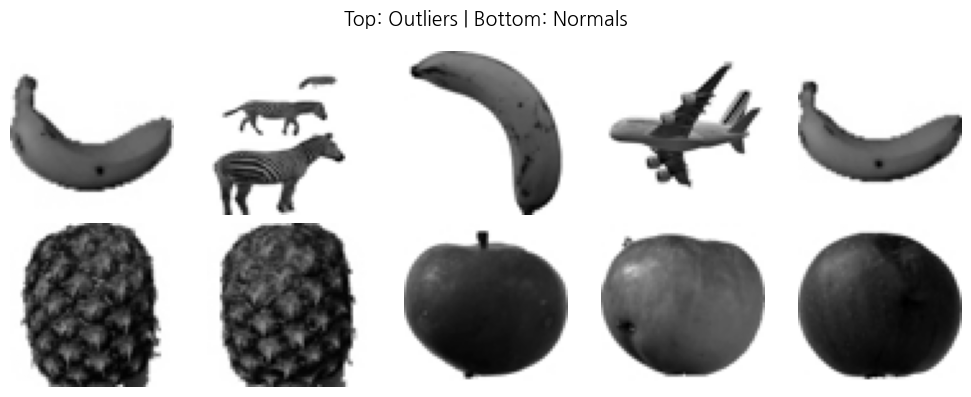

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

class Node:
    def __init__(self, idx, feature):
        self.idx = idx
        self.feature = feature
        self.neighbors = []
        self.updated_feature = feature.copy()

    def add_neighbor(self, neighbor):
        self.neighbors.append(neighbor)

    def aggregate(self):
        if not self.neighbors:
            return self.feature
        neighbor_features = [n.feature for n in self.neighbors]
        return np.mean(neighbor_features, axis=0)

    def update(self):
        self.updated_feature = (self.feature + self.aggregate()) / 2

def load_images_from_folder(folder, include_subfolders=False, img_size=(64, 64)):
    image_paths = []
    if include_subfolders:
        # 하위 폴더 포함 모든 이미지 경로 수집
        for root, _, files in os.walk(folder):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(root, f))
    else:
        # 최상위 폴더만 이미지 경로 수집
        for f in os.listdir(folder):
            full_path = os.path.join(folder, f)
            if os.path.isfile(full_path) and f.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(full_path)

    images = []
    for path in tqdm(image_paths, desc="Loading images"):
        img = Image.open(path).convert("L").resize(img_size)
        images.append(np.array(img).flatten())
    return np.array(images), image_paths

def build_graph(features, similarity_threshold=0.8):
    features = normalize(features)
    sim_matrix = cosine_similarity(features)
    nodes = [Node(i, f) for i, f in enumerate(features)]
    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if i != j and sim_matrix[i][j] > similarity_threshold:
                nodes[i].add_neighbor(nodes[j])
    return nodes

def run_gnn(nodes, epochs=1):
    for _ in range(epochs):
        for node in nodes:
            node.update()
        for node in nodes:
            node.feature = node.updated_feature.copy()
    return np.array([node.feature for node in nodes])

def detect_outliers(image_folder,
                    include_subfolders=False,
                    n_clusters=5,
                    outlier_ratio=0.1,
                    similarity_threshold=0.8,
                    gnn_epochs=1,
                    img_size=(64, 64)):
    features, image_paths = load_images_from_folder(image_folder, include_subfolders, img_size)
    if len(features) < n_clusters:
        raise ValueError(f"Number of images ({len(features)}) is less than the number of clusters ({n_clusters})")
    nodes = build_graph(features, similarity_threshold=similarity_threshold)
    embeddings = run_gnn(nodes, epochs=gnn_epochs)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    centers = kmeans.cluster_centers_

    dists = np.linalg.norm(embeddings - centers[labels], axis=1)
    cluster_errors = {i: [] for i in range(n_clusters)}
    for i, label in enumerate(labels):
        cluster_errors[label].append(dists[i])

    cluster_avg_error = {i: np.mean(cluster_errors[i]) for i in range(n_clusters)}
    sorted_clusters = sorted(cluster_avg_error.items(), key=lambda x: x[1], reverse=True)
    n_outlier_clusters = max(1, int(len(sorted_clusters) * outlier_ratio))
    outlier_cluster_ids = [cid for cid, _ in sorted_clusters[:n_outlier_clusters]]

    outlier_indices = [i for i, label in enumerate(labels) if label in outlier_cluster_ids]
    return [image_paths[i] for i in outlier_indices], image_paths, outlier_indices

def show_outliers_vs_normals(image_paths, outlier_indices, img_size=(64, 64), num_show=5):
    normal_indices = [i for i in range(len(image_paths)) if i not in outlier_indices]
    num_show = min(num_show, len(outlier_indices), len(normal_indices))

    if num_show == 0:
        print("시각화할 이상치 또는 정상 이미지가 충분하지 않습니다.")
        return

    fig, axes = plt.subplots(2, num_show, figsize=(num_show * 2, 4))
    fig.suptitle("Top: Outliers | Bottom: Normals", fontsize=14)
    for i in range(num_show):
        out_img = Image.open(image_paths[outlier_indices[i]]).convert("L").resize(img_size)
        norm_img = Image.open(image_paths[normal_indices[i]]).convert("L").resize(img_size)
        axes[0, i].imshow(out_img, cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(norm_img, cmap='gray')
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # 설정 예시
    image_folder = "imgData/mini_final"
    include_subfolders = False  # 하위폴더 포함할지 여부 선택
    n_clusters = 5
    outlier_ratio = 0.2
    similarity_threshold = 0.8
    gnn_epochs = 2
    img_size = (64, 64)

    outlier_paths, all_paths, outlier_indices = detect_outliers(
        image_folder=image_folder,
        include_subfolders=include_subfolders,
        n_clusters=n_clusters,
        outlier_ratio=outlier_ratio,
        similarity_threshold=similarity_threshold,
        gnn_epochs=gnn_epochs,
        img_size=img_size
    )

    print("Detected outliers:")
    outlier = 0
    total = 0
    for path in outlier_paths:
        print(path)
        if len(path.split('_'))==2:
          outlier = outlier + 1
        total = total + 1

    print(f"True outliers: {outlier}")
    print(f"Total outliers: {total}")


    show_outliers_vs_normals(all_paths, outlier_indices, img_size=img_size)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

class Node:
    def __init__(self, idx, feature):
        self.idx = idx
        self.feature = feature
        self.neighbors = []
        self.updated_feature = feature.copy()

    def add_neighbor(self, neighbor):
        self.neighbors.append(neighbor)

    def aggregate(self):
        if not self.neighbors:
            return self.feature
        neighbor_features = [n.feature for n in self.neighbors]
        return np.mean(neighbor_features, axis=0)

    def update(self):
        self.updated_feature = (self.feature + self.aggregate()) / 2

def load_images_from_folder(folder, include_subfolders=False, img_size=(64, 64)):
    image_paths = []
    if include_subfolders:
        # 하위 폴더 포함 모든 이미지 경로 수집
        for root, _, files in os.walk(folder):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(root, f))
    else:
        # 최상위 폴더만 이미지 경로 수집
        for f in os.listdir(folder):
            full_path = os.path.join(folder, f)
            if os.path.isfile(full_path) and f.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(full_path)

    images = []
    for path in tqdm(image_paths, desc="Loading images"):
        img = Image.open(path).convert("L").resize(img_size)
        images.append(np.array(img).flatten())
    return np.array(images), image_paths

def build_graph(features, similarity_threshold=0.8):
    features = normalize(features)
    sim_matrix = cosine_similarity(features)
    nodes = [Node(i, f) for i, f in enumerate(features)]
    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if i != j and sim_matrix[i][j] > similarity_threshold:
                nodes[i].add_neighbor(nodes[j])
    return nodes

def run_gnn(nodes, epochs=1):
    for _ in range(epochs):
        for node in nodes:
            node.update()
        for node in nodes:
            node.feature = node.updated_feature.copy()
    return np.array([node.feature for node in nodes])

def detect_outliers(image_folder,
                    include_subfolders=False,
                    n_clusters=5,
                    outlier_ratio=0.1,
                    similarity_threshold=0.8,
                    gnn_epochs=1,
                    img_size=(64, 64)):
    features, image_paths = load_images_from_folder(image_folder, include_subfolders, img_size)
    if len(features) < n_clusters:
        raise ValueError(f"Number of images ({len(features)}) is less than the number of clusters ({n_clusters})")
    nodes = build_graph(features, similarity_threshold=similarity_threshold)
    embeddings = run_gnn(nodes, epochs=gnn_epochs)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    centers = kmeans.cluster_centers_

    dists = np.linalg.norm(embeddings - centers[labels], axis=1)
    cluster_errors = {i: [] for i in range(n_clusters)}
    for i, label in enumerate(labels):
        cluster_errors[label].append(dists[i])

    cluster_avg_error = {i: np.mean(cluster_errors[i]) for i in range(n_clusters)}
    sorted_clusters = sorted(cluster_avg_error.items(), key=lambda x: x[1], reverse=True)
    n_outlier_clusters = max(1, int(len(sorted_clusters) * outlier_ratio))
    outlier_cluster_ids = [cid for cid, _ in sorted_clusters[:n_outlier_clusters]]

    outlier_indices = [i for i, label in enumerate(labels) if label in outlier_cluster_ids]
    return [image_paths[i] for i in outlier_indices], image_paths, outlier_indices

def show_outliers_vs_normals(image_paths, outlier_indices, img_size=(64, 64), num_show=5):
    normal_indices = [i for i in range(len(image_paths)) if i not in outlier_indices]
    num_show = min(num_show, len(outlier_indices), len(normal_indices))

    if num_show == 0:
        print("시각화할 이상치 또는 정상 이미지가 충분하지 않습니다.")
        return

    fig, axes = plt.subplots(2, num_show, figsize=(num_show * 2, 4))
    fig.suptitle("Top: Outliers | Bottom: Normals", fontsize=14)
    for i in range(num_show):
        out_img = Image.open(image_paths[outlier_indices[i]]).convert("L").resize(img_size)
        norm_img = Image.open(image_paths[normal_indices[i]]).convert("L").resize(img_size)
        axes[0, i].imshow(out_img, cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(norm_img, cmap='gray')
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()
from itertools import product

def tune_hyperparameters(image_folder,
                         include_subfolders,
                         n_clusters_list,
                         outlier_ratio_list,
                         similarity_threshold_list,
                         gnn_epochs_list,
                         img_size=(64, 64)):
    best_config = None
    best_score = None  # 예: 이상치 수 최대화 혹은 오차 최소화 등 기준 선택
    results = []

    for n_clusters, outlier_ratio, similarity_threshold, gnn_epochs in product(
        n_clusters_list, outlier_ratio_list, similarity_threshold_list, gnn_epochs_list):

        try:
            outlier_paths, all_paths, outlier_indices = detect_outliers(
                image_folder=image_folder,
                include_subfolders=include_subfolders,
                n_clusters=n_clusters,
                outlier_ratio=outlier_ratio,
                similarity_threshold=similarity_threshold,
                gnn_epochs=gnn_epochs,
                img_size=img_size
            )
            # 평가 기준 예시: 이상치 개수 (클수록 더 민감하게 이상치 탐지)
            score = len(outlier_paths)
            results.append({
                'n_clusters': n_clusters,
                'outlier_ratio': outlier_ratio,
                'similarity_threshold': similarity_threshold,
                'gnn_epochs': gnn_epochs,
                'outlier_count': score
            })

            # 여기서는 이상치 개수 최대화를 목표로 함
            if best_score is None or score > best_score:
                best_score = score
                best_config = (n_clusters, outlier_ratio, similarity_threshold, gnn_epochs)

        except Exception as e:
            print(f"Error with config (n_clusters={n_clusters}, outlier_ratio={outlier_ratio}, "
                  f"similarity_threshold={similarity_threshold}, gnn_epochs={gnn_epochs}): {e}")

    return best_config, best_score, results

# --- 사용 예시 ---

if __name__ == "__main__":
    image_folder = "image"
    include_subfolders = True

    n_clusters_list = [3, 5, 7]
    outlier_ratio_list = [0.1, 0.2]
    similarity_threshold_list = [0.75, 0.8]
    gnn_epochs_list = [1, 2]

    best_config, best_score, results = tune_hyperparameters(
        image_folder=image_folder,
        include_subfolders=include_subfolders,
        n_clusters_list=n_clusters_list,
        outlier_ratio_list=outlier_ratio_list,
        similarity_threshold_list=similarity_threshold_list,
        gnn_epochs_list=gnn_epochs_list,
        img_size=(64,64)
    )

    print("Best config:", best_config)
    print("Best outlier count:", best_score)
    print("All results:")
    for r in results:
        print(r)


Loading images: 100%|██████████| 7/7 [00:00<00:00, 35.50it/s]


Best config: (3, 0.1, 0.75, 1)
Best outlier count: 5
All results:
{'n_clusters': 3, 'outlier_ratio': 0.1, 'similarity_threshold': 0.75, 'gnn_epochs': 1, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.1, 'similarity_threshold': 0.75, 'gnn_epochs': 2, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.1, 'similarity_threshold': 0.8, 'gnn_epochs': 1, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.1, 'similarity_threshold': 0.8, 'gnn_epochs': 2, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.2, 'similarity_threshold': 0.75, 'gnn_epochs': 1, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.2, 'similarity_threshold': 0.75, 'gnn_epochs': 2, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.2, 'similarity_threshold': 0.8, 'gnn_epochs': 1, 'outlier_count': 5}
{'n_clusters': 3, 'outlier_ratio': 0.2, 'similarity_threshold': 0.8, 'gnn_epochs': 2, 'outlier_count': 5}
{'n_clusters': 5, 'outlier_ratio': 0.1, 'similarity_threshold': 0.75, 'gnn_epochs'

Best config: (3, 0.1, 0.75, 1)
Best outlier count: 230
Detected outliers:
imgData/mini_final/68_100.jpg
imgData/mini_final/000000000154.jpg
imgData/mini_final/r1_274_100.jpg
imgData/mini_final/000000000081.jpg
imgData/mini_final/r0_270_100.jpg
imgData/mini_final/r0_277_100.jpg
imgData/mini_final/r0_241_100.jpg
imgData/mini_final/79_100.jpg
imgData/mini_final/98_100.jpg
imgData/mini_final/r0_245_100.jpg
imgData/mini_final/70_100.jpg
imgData/mini_final/r1_259_100.jpg
imgData/mini_final/r0_273_100.jpg
imgData/mini_final/r1_266_100.jpg
imgData/mini_final/r0_179_100.jpg
imgData/mini_final/000000000092.jpg
imgData/mini_final/r0_249_100.jpg
imgData/mini_final/000000001381.jpg
imgData/mini_final/86_100.jpg
imgData/mini_final/000000001307.jpg
imgData/mini_final/r1_268_100.jpg
imgData/mini_final/000000001436.jpg
imgData/mini_final/000000001448.jpg
imgData/mini_final/r0_279_100.jpg
imgData/mini_final/77_100.jpg
imgData/mini_final/95_100.jpg
imgData/mini_final/61_100.jpg
imgData/mini_final/r0_237_

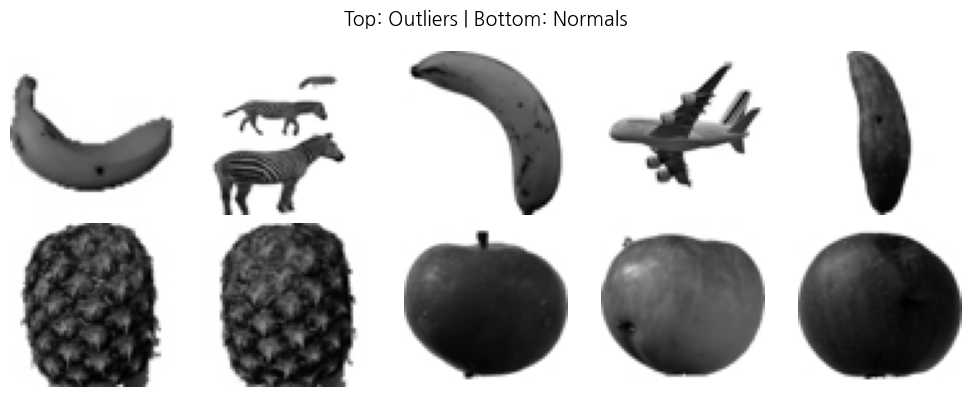

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from itertools import product

# --- Node 클래스 정의 ---
class Node:
    def __init__(self, feature, idx):
        self.feature = feature  # 이미지 벡터
        self.idx = idx          # 원본 이미지 인덱스
        self.neighbors = []
        self.state = feature.copy()  # GNN 상태 초기값

    def add_neighbor(self, neighbor):
        self.neighbors.append(neighbor)

    def update_state(self):
        if not self.neighbors:
            return
        agg = np.mean([n.state for n in self.neighbors], axis=0)
        self.state = 0.5 * self.state + 0.5 * agg  # simple mean aggregation

# --- 이미지 불러오기 ---
def load_images_from_folder(folder_path, include_subfolders=True, img_size=(64,64)):
    image_paths = []
    if include_subfolders:
        for root, _, files in os.walk(folder_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    image_paths.append(os.path.join(root, file))
    else:
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                image_paths.append(os.path.join(folder_path, file))

    features = []
    for path in image_paths:
        img = Image.open(path).convert("L").resize(img_size)
        features.append(np.array(img).flatten() / 255.0)  # 정규화 후 1D 벡터로 변환
    return features, image_paths

# --- 그래프 생성 ---
def build_graph(nodes, similarity_threshold=0.8):
    for i, node_i in enumerate(nodes):
        for j in range(i+1, len(nodes)):
            node_j = nodes[j]
            sim = cosine_similarity(node_i.feature, node_j.feature)
            if sim >= similarity_threshold:
                node_i.add_neighbor(node_j)
                node_j.add_neighbor(node_i)

def cosine_similarity(a, b):
    if np.linalg.norm(a)==0 or np.linalg.norm(b)==0:
        return 0
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# --- GNN 업데이트 ---
def run_gnn(nodes, epochs=2):
    for _ in range(epochs):
        new_states = []
        for node in nodes:
            if not node.neighbors:
                new_states.append(node.state)
                continue
            agg = np.mean([n.state for n in node.neighbors], axis=0)
            new_state = 0.5 * node.state + 0.5 * agg
            new_states.append(new_state)
        for node, ns in zip(nodes, new_states):
            node.state = ns

# --- 군집화 후 이상치 탐지 ---
def cluster_and_detect_outliers(nodes, n_clusters=3, outlier_ratio=0.1):
    X = np.array([node.state for node in nodes])
    if len(X) < n_clusters:
        n_clusters = max(1, len(X))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    # 각 노드가 클러스터 중심과 얼마나 차이나는지 계산 (오차)
    errors = np.linalg.norm(X - centers[labels], axis=1)

    # 클러스터별 평균 오차 계산
    cluster_errors = []
    for c in range(n_clusters):
        cluster_errors.append(np.mean(errors[labels==c]))

    # 오차 기준 상위 outlier_ratio만큼 클러스터 선택
    num_outlier_clusters = max(1, int(n_clusters * outlier_ratio))
    outlier_cluster_indices = np.argsort(cluster_errors)[-num_outlier_clusters:]

    # 이상치 노드 인덱스 추출
    outlier_indices = [i for i, label in enumerate(labels) if label in outlier_cluster_indices]

    return outlier_indices

# --- 이상치 및 정상 이미지 시각화 ---
def show_outliers_vs_normals(image_paths, outlier_indices, img_size=(64, 64), num_show=5):
    normal_indices = [i for i in range(len(image_paths)) if i not in outlier_indices]
    num_show = min(num_show, len(outlier_indices), len(normal_indices))
    if num_show == 0:
        print("시각화할 이상치 또는 정상 이미지가 충분하지 않습니다.")
        return

    fig, axes = plt.subplots(2, num_show, figsize=(num_show * 2, 4))
    fig.suptitle("Top: Outliers | Bottom: Normals", fontsize=14)

    if num_show == 1:
        # axes가 1차원 배열 (길이 2)
        axes_outliers = axes[0]
        axes_normals = axes[1]
        out_img = Image.open(image_paths[outlier_indices[0]]).convert("L").resize(img_size)
        norm_img = Image.open(image_paths[normal_indices[0]]).convert("L").resize(img_size)
        axes_outliers.imshow(out_img, cmap='gray')
        axes_outliers.axis('off')
        axes_normals.imshow(norm_img, cmap='gray')
        axes_normals.axis('off')
    else:
        for i in range(num_show):
            out_img = Image.open(image_paths[outlier_indices[i]]).convert("L").resize(img_size)
            norm_img = Image.open(image_paths[normal_indices[i]]).convert("L").resize(img_size)
            axes[0, i].imshow(out_img, cmap='gray')
            axes[0, i].axis('off')
            axes[1, i].imshow(norm_img, cmap='gray')
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# --- 전체 파이프라인 ---
def detect_outliers(image_folder,
                    include_subfolders=True,
                    n_clusters=3,
                    outlier_ratio=0.1,
                    similarity_threshold=0.8,
                    gnn_epochs=2,
                    img_size=(64, 64)):
    features, image_paths = load_images_from_folder(image_folder, include_subfolders, img_size)
    if len(features) == 0:
        print("이미지를 찾을 수 없습니다.")
        return [], [], []

    nodes = [Node(f, idx) for idx, f in enumerate(features)]
    build_graph(nodes, similarity_threshold)
    run_gnn(nodes, gnn_epochs)
    outlier_indices = cluster_and_detect_outliers(nodes, n_clusters, outlier_ratio)
    outlier_paths = [image_paths[i] for i in outlier_indices]
    return outlier_paths, image_paths, outlier_indices

# --- 하이퍼파라미터 튜닝 자동화 ---
def tune_hyperparameters(image_folder,
                         include_subfolders,
                         n_clusters_list,
                         outlier_ratio_list,
                         similarity_threshold_list,
                         gnn_epochs_list,
                         img_size=(64, 64)):
    best_config = None
    best_score = None
    results = []

    for n_clusters, outlier_ratio, similarity_threshold, gnn_epochs in product(
        n_clusters_list, outlier_ratio_list, similarity_threshold_list, gnn_epochs_list):

        try:
            outlier_paths, all_paths, outlier_indices = detect_outliers(
                image_folder=image_folder,
                include_subfolders=include_subfolders,
                n_clusters=n_clusters,
                outlier_ratio=outlier_ratio,
                similarity_threshold=similarity_threshold,
                gnn_epochs=gnn_epochs,
                img_size=img_size
            )
            score = len(outlier_paths)  # 이상치 개수 기준 예시
            results.append({
                'n_clusters': n_clusters,
                'outlier_ratio': outlier_ratio,
                'similarity_threshold': similarity_threshold,
                'gnn_epochs': gnn_epochs,
                'outlier_count': score
            })

            if best_score is None or score > best_score:
                best_score = score
                best_config = (n_clusters, outlier_ratio, similarity_threshold, gnn_epochs)

        except Exception as e:
            print(f"Error with config (n_clusters={n_clusters}, outlier_ratio={outlier_ratio}, "
                  f"similarity_threshold={similarity_threshold}, gnn_epochs={gnn_epochs}): {e}")

    return best_config, best_score, results

# --- 실행 예시 ---
if __name__ == "__main__":
    image_folder = "imgData"  # 이미지 폴더 경로 지정
    include_subfolders = True  # 하위 폴더 포함 여부

    # 하이퍼파라미터 후보값 설정
    n_clusters_list = [3, 5, 7]
    outlier_ratio_list = [0.1, 0.2]
    similarity_threshold_list = [0.75, 0.8]
    gnn_epochs_list = [1, 2]

    # 하이퍼파라미터 튜닝 실행
    best_config, best_score, results = tune_hyperparameters(
        image_folder=image_folder,
        include_subfolders=include_subfolders,
        n_clusters_list=n_clusters_list,
        outlier_ratio_list=outlier_ratio_list,
        similarity_threshold_list=similarity_threshold_list,
        gnn_epochs_list=gnn_epochs_list,
        img_size=(64, 64)
    )

    print("Best config:", best_config)
    print("Best outlier count:", best_score)

    # 튜닝된 최적값으로 이상치 탐지 및 시각화
    outlier_paths, all_paths, outlier_indices = detect_outliers(
        image_folder=image_folder,
        include_subfolders=include_subfolders,
        n_clusters=best_config[0],
        outlier_ratio=best_config[1],
        similarity_threshold=best_config[2],
        gnn_epochs=best_config[3],
        img_size=(64, 64)
    )

    print("Detected outliers:")
    for path in outlier_paths:
        print(path)

    show_outliers_vs_normals(all_paths, outlier_indices, img_size=(64, 64), num_show=5)


Loading images: 100%|██████████| 500/500 [00:00<00:00, 1680.75it/s]


Best Hyperparameter Configuration:
{'num_clusters': 3, 'top_outlier_percent': 0.1, 'gnn_steps': 2, 'include_subfolders': True}

Detected Outlier Files:
imgData/mini_final/68_100.jpg
imgData/mini_final/000000000154.jpg
imgData/mini_final/r1_274_100.jpg
imgData/mini_final/000000000081.jpg
imgData/mini_final/r0_270_100.jpg
imgData/mini_final/r0_277_100.jpg
imgData/mini_final/r0_241_100.jpg
imgData/mini_final/79_100.jpg
imgData/mini_final/98_100.jpg
imgData/mini_final/r0_245_100.jpg
imgData/mini_final/70_100.jpg
imgData/mini_final/r1_259_100.jpg
imgData/mini_final/r0_273_100.jpg
imgData/mini_final/r1_266_100.jpg
imgData/mini_final/r0_179_100.jpg
imgData/mini_final/000000000092.jpg
imgData/mini_final/r0_249_100.jpg
imgData/mini_final/000000001381.jpg
imgData/mini_final/86_100.jpg
imgData/mini_final/000000001307.jpg
imgData/mini_final/r1_268_100.jpg
imgData/mini_final/000000001436.jpg
imgData/mini_final/000000001448.jpg
imgData/mini_final/r0_279_100.jpg
imgData/mini_final/77_100.jpg
imgData/

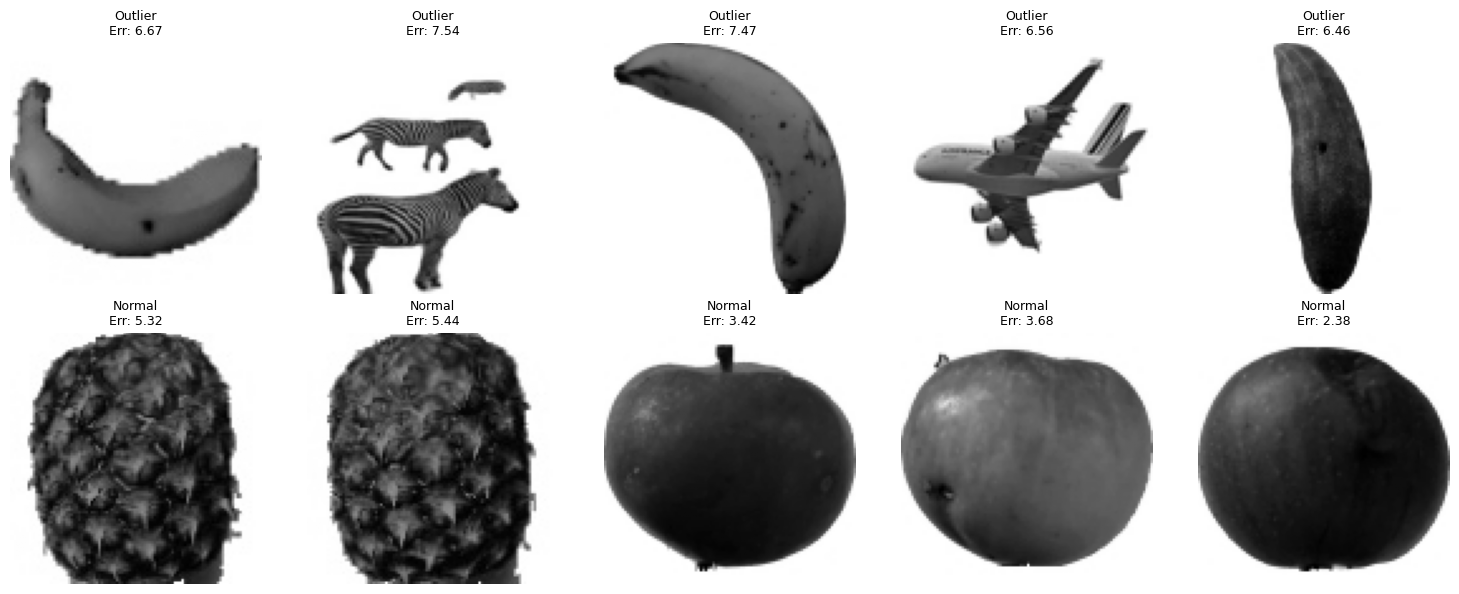

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
from itertools import product
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

# ----------------------------
# Hyperparameters
# ----------------------------
def get_hyperparameter_grid():
    return {
        "num_clusters": [3, 5, 8],
        "top_outlier_percent": [0.1, 0.2],
        "gnn_steps": [1, 2],
        "include_subfolders": [True, False]
    }

# ----------------------------
# Image loading and flattening
# ----------------------------
def load_images_from_folder(folder, size=(64, 64), include_subfolders=True):
    image_paths = []
    for root, dirs, files in os.walk(folder):
        if not include_subfolders and root != folder:
            continue
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg', 'bmp')):
                image_paths.append(os.path.join(root, file))

    vectors = []
    for path in tqdm(image_paths, desc="Loading images"):
        try:
            img = Image.open(path).convert("L").resize(size)
            vectors.append(np.asarray(img).flatten() / 255.0)
        except:
            continue

    return np.array(vectors), image_paths

# ----------------------------
# GNN-inspired node class
# ----------------------------
class Node:
    def __init__(self, features):
        self.features = features
        self.state = features.copy()

    def update(self, neighbors):
        if not neighbors:
            return
        neighbor_states = np.array([n.state for n in neighbors])
        self.state = 0.5 * self.state + 0.5 * neighbor_states.mean(axis=0)

# ----------------------------
# Build similarity-based graph
# ----------------------------
def build_graph(vectors, threshold=0.5):
    nodes = [Node(vec) for vec in vectors]
    edges = [[] for _ in range(len(nodes))]
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            sim = np.dot(nodes[i].features, nodes[j].features)
            if sim > threshold:
                edges[i].append(nodes[j])
                edges[j].append(nodes[i])
    return nodes, edges

# ----------------------------
# GNN state propagation
# ----------------------------
def gnn_propagate(nodes, edges, steps):
    for _ in range(steps):
        for i, node in enumerate(nodes):
            node.update(edges[i])

# ----------------------------
# Clustering & Outlier Detection
# ----------------------------
def find_outliers_from_clusters(vectors, image_paths, num_clusters=5, top_percent=0.1):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    labels = kmeans.fit_predict(vectors)
    distances = kmeans.transform(vectors)
    min_distances = distances.min(axis=1)

    cluster_errors = [[] for _ in range(num_clusters)]
    for i, (label, dist) in enumerate(zip(labels, min_distances)):
        cluster_errors[label].append((i, dist))

    cluster_avg_error = [np.mean([e[1] for e in group]) if group else 0 for group in cluster_errors]
    num_top_clusters = max(1, int(num_clusters * top_percent))
    worst_clusters = np.argsort(cluster_avg_error)[-num_top_clusters:]

    outlier_indices = [idx for cluster in worst_clusters for idx, _ in cluster_errors[cluster]]
    return outlier_indices, min_distances

# ----------------------------
# Visualization with labels and distances
# ----------------------------
def show_outliers_vs_normals_with_info(image_paths, outlier_indices, distances, img_size=(64, 64), num_show=5, true_labels=None):
    num_outliers = len(outlier_indices)
    num_show = min(num_show, num_outliers)

    if num_show == 0:
        print("No outliers to display.")
        return

    normal_indices = [i for i in range(len(image_paths)) if i not in outlier_indices]
    if len(normal_indices) < num_show:
        print("Not enough normal samples for comparison.")
        return

    fig = plt.figure(figsize=(num_show * 3, 6))
    spec = gridspec.GridSpec(2, num_show)

    for i in range(num_show):
        out_idx = outlier_indices[i]
        norm_idx = normal_indices[i]

        out_img = Image.open(image_paths[out_idx]).convert("L").resize(img_size)
        norm_img = Image.open(image_paths[norm_idx]).convert("L").resize(img_size)

        ax1 = fig.add_subplot(spec[0, i])
        ax1.imshow(out_img, cmap='gray')
        ax1.axis('off')
        title1 = f"Outlier\nErr: {distances[out_idx]:.2f}"
        if true_labels:
            title1 += f"\nLabel: {true_labels[out_idx]}"
        ax1.set_title(title1, fontsize=9)

        ax2 = fig.add_subplot(spec[1, i])
        ax2.imshow(norm_img, cmap='gray')
        ax2.axis('off')
        title2 = f"Normal\nErr: {distances[norm_idx]:.2f}"
        if true_labels:
            title2 += f"\nLabel: {true_labels[norm_idx]}"
        ax2.set_title(title2, fontsize=9)

    plt.tight_layout()
    plt.show()

# ----------------------------
# Auto hyperparameter tuning
# ----------------------------
def auto_tune_hyperparams(folder, img_size=(64, 64)):
    grid = get_hyperparameter_grid()
    best_config = None
    best_score = -1
    best_outliers = []
    best_vectors = []
    best_paths = []
    best_distances = []

    for config in product(*grid.values()):
        config_dict = dict(zip(grid.keys(), config))
        vectors, paths = load_images_from_folder(folder, size=img_size, include_subfolders=config_dict["include_subfolders"])
        if len(vectors) < config_dict["num_clusters"]:
            continue

        nodes, edges = build_graph(vectors)
        gnn_propagate(nodes, edges, config_dict["gnn_steps"])
        updated_vectors = np.array([n.state for n in nodes])

        outlier_indices, distances = find_outliers_from_clusters(
            updated_vectors, paths,
            num_clusters=config_dict["num_clusters"],
            top_percent=config_dict["top_outlier_percent"]
        )

        score = len(outlier_indices)
        if score > best_score:
            best_score = score
            best_config = config_dict
            best_outliers = outlier_indices
            best_vectors = updated_vectors
            best_paths = paths
            best_distances = distances

    return best_config, best_outliers, best_vectors, best_paths, best_distances

# ----------------------------
# Entry point
# ----------------------------
if __name__ == "__main__":
    folder = "imgData/mini_final"  # change this to your actual image folder path
    img_size = (100, 100)

    best_config, outlier_indices, vectors, all_paths, distances = auto_tune_hyperparams(folder, img_size)

    print("Best Hyperparameter Configuration:")
    print(best_config)

    print("\nDetected Outlier Files:")
    for idx in outlier_indices:
        print(all_paths[idx])

    show_outliers_vs_normals_with_info(
        image_paths=all_paths,
        outlier_indices=outlier_indices,
        distances=distances,
        img_size=img_size,
        num_show=5,
        true_labels=None  # If available, you can add true labels here
    )


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from tqdm import tqdm

# ----- 하이퍼파라미터 -----
embedding_dim = 128
hidden_dim = 64
num_neighbors = 5
num_epochs = 10
learning_rate = 0.01
outlier_threshold = 2.0  # z-score 기준
use_subdirs = True
image_dir = "./images"

# ----- 이미지 로딩 및 임베딩 -----
def get_image_paths(image_dir, use_subdirs):
    paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                paths.append(os.path.join(root, file))
        if not use_subdirs:
            break
    return paths

class ImageEncoder(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        base = models.resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        self.proj = nn.Linear(512, output_dim)

    def forward(self, x):
        x = self.feature_extractor(x).squeeze()
        return self.proj(x)

def extract_embeddings(image_paths, encoder, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    embeddings = []
    encoder.eval()
    with torch.no_grad():
        for path in tqdm(image_paths):
            img = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
            emb = encoder(img).cpu().numpy().flatten()
            embeddings.append(emb)
    return np.array(embeddings)

# ----- Node 정의 및 Graph 구성 -----
class Node:
    def __init__(self, idx, embedding):
        self.idx = idx
        self.embedding = embedding
        self.neighbors = []

def build_graph(embeddings, k=5):
    nodes = [Node(i, emb) for i, emb in enumerate(embeddings)]
    sims = cosine_similarity(embeddings)
    for i, node in enumerate(nodes):
        topk = np.argsort(-sims[i])[1:k+1]
        node.neighbors = [nodes[j] for j in topk]
    return nodes

# ----- GraphSAGE 수동 구현 -----
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)

    def forward(self, nodes, embeddings):
        new_embeddings = []
        for node in nodes:
            if node.neighbors:
                neighbor_embs = torch.stack([embeddings[n.idx] for n in node.neighbors])
                agg = neighbor_embs.mean(dim=0)
            else:
                agg = torch.zeros_like(embeddings[node.idx])
            combined = torch.cat([embeddings[node.idx], agg])
            new_emb = self.linear(combined)
            new_embeddings.append(new_emb)
        return torch.stack(new_embeddings)

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.sage1 = GraphSAGELayer(in_dim, hidden_dim)
        self.sage2 = GraphSAGELayer(hidden_dim, hidden_dim)

    def forward(self, nodes):
        emb = torch.stack([torch.tensor(n.embedding, dtype=torch.float32) for n in nodes])
        emb1 = F.relu(self.sage1(nodes, emb))
        emb2 = self.sage2(nodes, emb1)
        return emb2

# ----- 이상치 탐지 -----
def detect_outliers(gnn_embeddings, threshold=2.0):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(gnn_embeddings)
    dists = np.linalg.norm(scaled - scaled.mean(axis=0), axis=1)
    z_scores = (dists - dists.mean()) / dists.std()
    return np.where(z_scores > threshold)[0]

# ----- 시각화 -----
def visualize_with_clusters(embeddings, outlier_indices, image_paths, n_clusters=5):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(reduced[:, 0], reduced[:, 1], c=colors, s=60, picker=True)

    for i in outlier_indices:
        ax.scatter(reduced[i][0], reduced[i][1], edgecolors='black', facecolors='none', s=120, linewidths=2)

    ax.set_title("t-SNE with KMeans Clusters and Outliers")
    ax.legend(*scatter.legend_elements(), title="Clusters")

    def onpick(event):
        ind = event.ind[0]
        img_path = image_paths[ind]
        img = Image.open(img_path).convert("RGB")
        img.thumbnail((150, 150), Image.LANCZOS)
        imagebox = OffsetImage(np.array(img), zoom=1)
        ab = AnnotationBbox(imagebox, reduced[ind], frameon=True)
        ax.add_artist(ab)
        fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', onpick)
    plt.show()

# ----- 메인 실행 -----
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    image_paths = get_image_paths(image_dir, use_subdirs)
    encoder = ImageEncoder(embedding_dim).to(device)
    embeddings = extract_embeddings(image_paths, encoder, device)
    nodes = build_graph(embeddings, num_neighbors)

    model = GraphSAGE(embedding_dim, hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        gnn_out = model(nodes)
        loss = gnn_out.norm(dim=1).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    model.eval()
    final_embs = model(nodes).detach().cpu().numpy()
    outliers = detect_outliers(final_embs, outlier_threshold)

    print("\nDetected Outliers:")
    for idx in outliers:
        print(image_paths[idx])

    visualize_with_clusters(final_embs, outliers, image_paths, n_clusters=5)

if __name__ == "__main__":
    main()


In [ ]:
pip install torch torchvision matplotlib scikit-learn pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]
Extracting embeddings: 100%|██████████| 500/500 [00:51<00:00,  9.63it/s]


Epoch 1, Loss: 1.2453
Epoch 2, Loss: 2.6311
Epoch 3, Loss: 0.8011
Epoch 4, Loss: 0.3835
Epoch 5, Loss: 0.3573
Epoch 6, Loss: 0.3171
Epoch 7, Loss: 0.2725
Epoch 8, Loss: 0.2262
Epoch 9, Loss: 0.1806
Epoch 10, Loss: 0.1384

Detected Outliers:


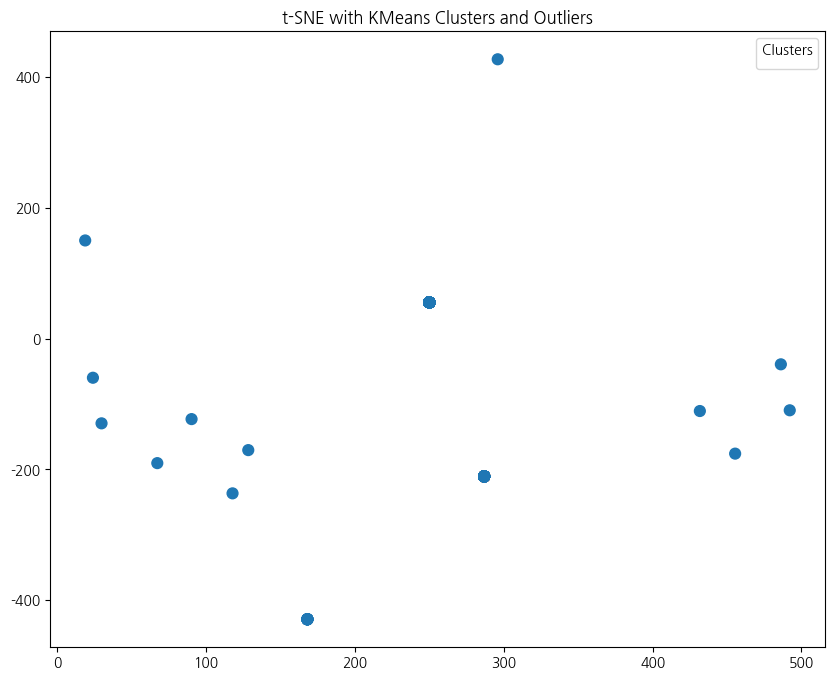

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from tqdm import tqdm

# 이미지 경로 수집
def get_image_paths(image_dir, use_subdirs):
    paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                paths.append(os.path.join(root, file))
        if not use_subdirs:
            break
    return paths

# 이미지 임베딩 추출기 정의
class ImageEncoder(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        base = models.resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        self.proj = nn.Linear(512, output_dim)

    def forward(self, x):
        x = self.feature_extractor(x).squeeze()
        return self.proj(x)

# 이미지에서 임베딩 추출
def extract_embeddings(image_paths, encoder, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    embeddings = []
    encoder.eval()
    with torch.no_grad():
        for path in tqdm(image_paths, desc="Extracting embeddings"):
            img = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
            emb = encoder(img).cpu().numpy().flatten()
            embeddings.append(emb)
    return np.array(embeddings)

# Node 클래스
class Node:
    def __init__(self, idx, embedding):
        self.idx = idx
        self.embedding = embedding
        self.neighbors = []

# 그래프 구성
def build_graph(embeddings, k=5):
    nodes = [Node(i, emb) for i, emb in enumerate(embeddings)]
    sims = cosine_similarity(embeddings)
    for i, node in enumerate(nodes):
        topk = np.argsort(-sims[i])[1:k+1]
        node.neighbors = [nodes[j] for j in topk]
    return nodes

# GraphSAGE 레이어
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)

    def forward(self, nodes, embeddings):
        new_embeddings = []
        for node in nodes:
            if node.neighbors:
                neighbor_embs = torch.stack([embeddings[n.idx] for n in node.neighbors])
                agg = neighbor_embs.mean(dim=0)
            else:
                agg = torch.zeros_like(embeddings[node.idx])
            combined = torch.cat([embeddings[node.idx], agg])
            new_emb = self.linear(combined)
            new_embeddings.append(new_emb)
        return torch.stack(new_embeddings)

# GraphSAGE 모델
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.sage1 = GraphSAGELayer(in_dim, hidden_dim)
        self.sage2 = GraphSAGELayer(hidden_dim, hidden_dim)

    def forward(self, nodes):
        emb = torch.stack([torch.tensor(n.embedding, dtype=torch.float32) for n in nodes])
        emb1 = F.relu(self.sage1(nodes, emb))
        emb2 = self.sage2(nodes, emb1)
        return emb2

# 이상치 탐지 (z-score)
def detect_outliers(gnn_embeddings, threshold=2.0):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(gnn_embeddings)
    dists = np.linalg.norm(scaled - scaled.mean(axis=0), axis=1)
    z_scores = (dists - dists.mean()) / dists.std()
    return np.where(z_scores > threshold)[0]

# 시각화
def visualize_with_clusters(embeddings, outlier_indices, image_paths, n_clusters=5):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(reduced[:, 0], reduced[:, 1], c=colors, s=60, picker=True)

    for i in outlier_indices:
        ax.scatter(reduced[i][0], reduced[i][1], edgecolors='black', facecolors='none', s=120, linewidths=2)

    ax.set_title("t-SNE with KMeans Clusters and Outliers")
    ax.legend(*scatter.legend_elements(), title="Clusters")

    def onpick(event):
        ind = event.ind[0]
        img_path = image_paths[ind]
        img = Image.open(img_path).convert("RGB")
        img.thumbnail((150, 150), Image.LANCZOS)
        imagebox = OffsetImage(np.array(img), zoom=1)
        ab = AnnotationBbox(imagebox, reduced[ind], frameon=True)
        ax.add_artist(ab)
        fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', onpick)
    plt.show()

# 메인 함수
def main(config):
    image_dir = config["image_dir"]
    use_subdirs = config["use_subdirs"]
    embedding_dim = config["embedding_dim"]
    hidden_dim = config["hidden_dim"]
    num_neighbors = config["num_neighbors"]
    num_epochs = config["num_epochs"]
    learning_rate = config["learning_rate"]
    outlier_threshold = config["outlier_threshold"]
    n_clusters = config["n_clusters"]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    image_paths = get_image_paths(image_dir, use_subdirs)
    encoder = ImageEncoder(embedding_dim).to(device)
    embeddings = extract_embeddings(image_paths, encoder, device)
    nodes = build_graph(embeddings, num_neighbors)

    model = GraphSAGE(embedding_dim, hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        gnn_out = model(nodes)
        loss = gnn_out.norm(dim=1).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    model.eval()
    final_embs = model(nodes).detach().cpu().numpy()
    outliers = detect_outliers(final_embs, outlier_threshold)

    print("\nDetected Outliers:")
    for idx in outliers:
        print(image_paths[idx])

    visualize_with_clusters(final_embs, outliers, image_paths, n_clusters=n_clusters)

# 실행부 - 하이퍼파라미터 설정
if __name__ == "__main__":
    config = {
        "image_dir": "imgData/mini_final",       # 이미지 폴더 경로
        "use_subdirs": False,           # 하위 폴더 포함 여부
        "embedding_dim": 128,          # 이미지 임베딩 차원
        "hidden_dim": 64,              # GNN 은닉 차원
        "num_neighbors": 5,            # KNN 그래프 이웃 수
        "num_epochs": 10,              # 학습 반복 횟수
        "learning_rate": 0.01,         # 학습률
        "outlier_threshold": 2.0,      # 이상치 탐지 임계값 (Z-score)
        "n_clusters": 5                # 시각화 클러스터 수
    }
    main(config)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Extracting embeddings: 100%|██████████| 500/500 [00:56<00:00,  8.92it/s]


Epoch 1, Loss: 1.3156
Epoch 2, Loss: 3.6970
Epoch 3, Loss: 0.8666
Epoch 4, Loss: 0.3843
Epoch 5, Loss: 0.3586
Epoch 6, Loss: 0.3218
Epoch 7, Loss: 0.2802
Epoch 8, Loss: 0.2364
Epoch 9, Loss: 0.1924
Epoch 10, Loss: 0.1498
Epoch 11, Loss: 0.1111
Epoch 12, Loss: 0.0821
Epoch 13, Loss: 0.0706
Epoch 14, Loss: 0.0753
Epoch 15, Loss: 0.0846
Epoch 16, Loss: 0.0912
Epoch 17, Loss: 0.0934
Epoch 18, Loss: 0.0915
Epoch 19, Loss: 0.0869
Epoch 20, Loss: 0.0811


<ipython-input-14-1ad7533494c9>:107: RuntimeWarning: invalid value encountered in divide
  z_scores = (dists - dists.mean()) / dists.std()



Detected Outliers:


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/matplotlib/collections.py:1121: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


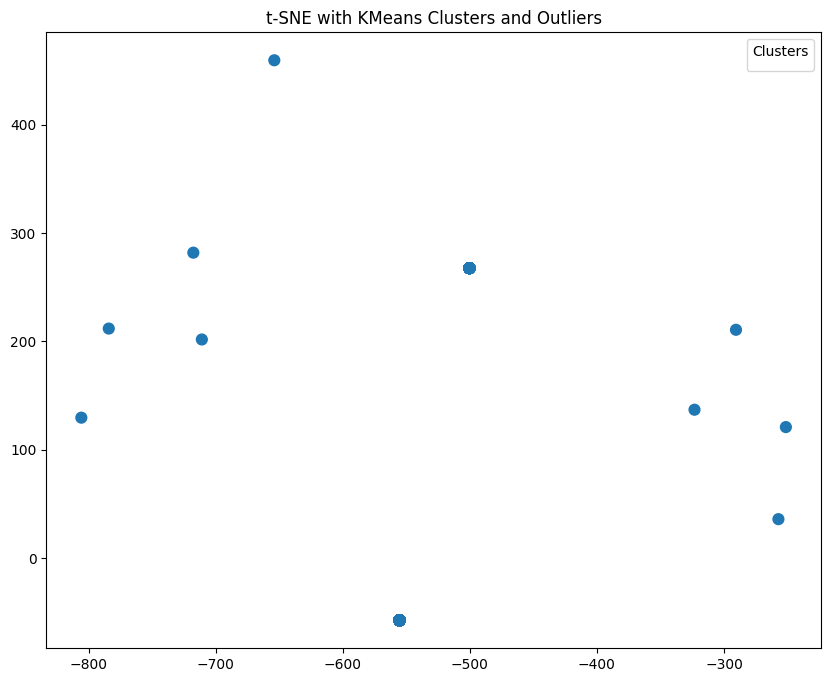

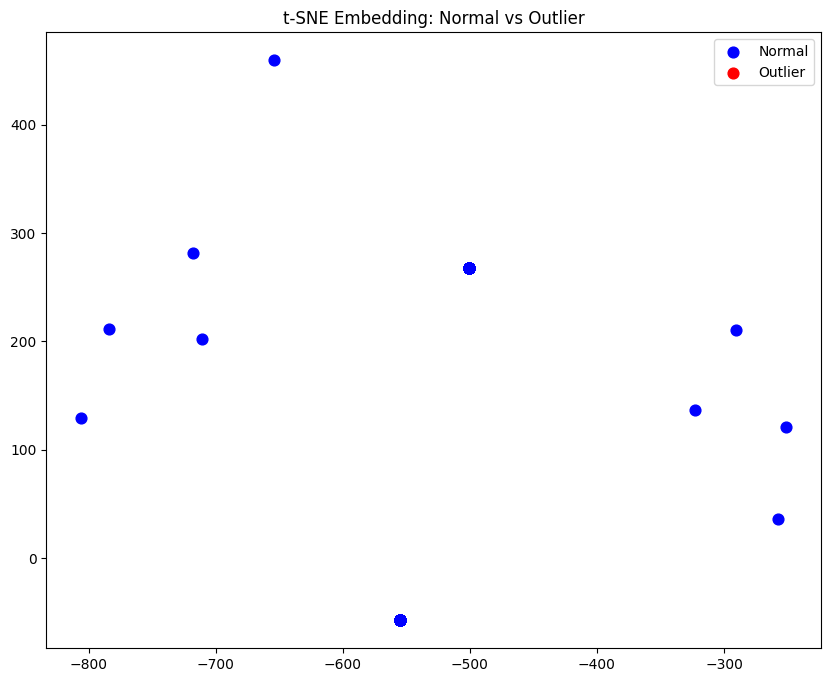

총 이미지 개수: 500
임베딩 shape: (500, 64)
이상치 인덱스: []


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from tqdm import tqdm

# 이미지 경로 수집
def get_image_paths(image_dir, use_subdirs):
    paths = []
    for root, _, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                paths.append(os.path.join(root, file))
        if not use_subdirs:
            break
    return paths

# 이미지 임베딩 추출기 정의
class ImageEncoder(nn.Module):
    def __init__(self, output_dim):
        super().__init__()
        base = models.resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])
        self.proj = nn.Linear(512, output_dim)

    def forward(self, x):
        x = self.feature_extractor(x).squeeze()
        return self.proj(x)

# 이미지에서 임베딩 추출
def extract_embeddings(image_paths, encoder, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    embeddings = []
    encoder.eval()
    with torch.no_grad():
        for path in tqdm(image_paths, desc="Extracting embeddings"):
            img = transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
            emb = encoder(img).cpu().numpy().flatten()
            embeddings.append(emb)
    return np.array(embeddings)

# Node 클래스
class Node:
    def __init__(self, idx, embedding):
        self.idx = idx
        self.embedding = embedding
        self.neighbors = []

# 그래프 구성
def build_graph(embeddings, k=5):
    nodes = [Node(i, emb) for i, emb in enumerate(embeddings)]
    sims = cosine_similarity(embeddings)
    for i, node in enumerate(nodes):
        topk = np.argsort(-sims[i])[1:k+1]
        node.neighbors = [nodes[j] for j in topk]
    return nodes

# GraphSAGE 레이어
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)

    def forward(self, nodes, embeddings):
        new_embeddings = []
        for node in nodes:
            if node.neighbors:
                neighbor_embs = torch.stack([embeddings[n.idx] for n in node.neighbors])
                agg = neighbor_embs.mean(dim=0)
            else:
                agg = torch.zeros_like(embeddings[node.idx])
            combined = torch.cat([embeddings[node.idx], agg])
            new_emb = self.linear(combined)
            new_embeddings.append(new_emb)
        return torch.stack(new_embeddings)

# GraphSAGE 모델
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.sage1 = GraphSAGELayer(in_dim, hidden_dim)
        self.sage2 = GraphSAGELayer(hidden_dim, hidden_dim)

    def forward(self, nodes):
        emb = torch.stack([torch.tensor(n.embedding, dtype=torch.float32) for n in nodes])
        emb1 = F.relu(self.sage1(nodes, emb))
        emb2 = self.sage2(nodes, emb1)
        return emb2

# 이상치 탐지 (z-score)
def detect_outliers(gnn_embeddings, threshold=2.0):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(gnn_embeddings)
    dists = np.linalg.norm(scaled - scaled.mean(axis=0), axis=1)
    z_scores = (dists - dists.mean()) / dists.std()
    return np.where(z_scores > threshold)[0]

# 군집 기반 시각화
def visualize_with_clusters(embeddings, outlier_indices, image_paths, n_clusters=5):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(reduced[:, 0], reduced[:, 1], c=colors, s=60, picker=True)

    for i in outlier_indices:
        ax.scatter(reduced[i][0], reduced[i][1], edgecolors='black', facecolors='none', s=120, linewidths=2)

    ax.set_title("t-SNE with KMeans Clusters and Outliers")
    ax.legend(*scatter.legend_elements(), title="Clusters")

    def onpick(event):
        ind = event.ind[0]
        img_path = image_paths[ind]
        img = Image.open(img_path).convert("RGB")
        img.thumbnail((150, 150), Image.LANCZOS)
        imagebox = OffsetImage(np.array(img), zoom=1)
        ab = AnnotationBbox(imagebox, reduced[ind], frameon=True)
        ax.add_artist(ab)
        fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', onpick)
    plt.show()

# 이상치 vs 정상이미지 시각화
def visualize_outliers_vs_normals(embeddings, outlier_indices, image_paths):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(10, 8))
    outlier_mask = np.zeros(len(embeddings), dtype=bool)
    outlier_mask[outlier_indices] = True

    normal_pts = reduced[~outlier_mask]
    outlier_pts = reduced[outlier_mask]

    ax.scatter(normal_pts[:, 0], normal_pts[:, 1], c='blue', label='Normal', s=60, picker=True)
    ax.scatter(outlier_pts[:, 0], outlier_pts[:, 1], c='red', label='Outlier', s=60, picker=True)

    ax.legend()
    ax.set_title("t-SNE Embedding: Normal vs Outlier")

    def onpick(event):
        ind = event.ind[0]
        if ind >= len(image_paths): return
        img_path = image_paths[ind]
        img = Image.open(img_path).convert("RGB")
        img.thumbnail((150, 150), Image.LANCZOS)
        imagebox = OffsetImage(np.array(img), zoom=1)
        ab = AnnotationBbox(imagebox, reduced[ind], frameon=True)
        ax.add_artist(ab)
        fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', onpick)
    plt.show()

# 메인 함수

def main(config):
    image_dir = config["image_dir"]
    use_subdirs = config["use_subdirs"]
    embedding_dim = config["embedding_dim"]
    hidden_dim = config["hidden_dim"]
    num_neighbors = config["num_neighbors"]
    num_epochs = config["num_epochs"]
    learning_rate = config["learning_rate"]
    outlier_threshold = config["outlier_threshold"]
    n_clusters = config["n_clusters"]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    image_paths = get_image_paths(image_dir, use_subdirs)
    encoder = ImageEncoder(embedding_dim).to(device)
    embeddings = extract_embeddings(image_paths, encoder, device)
    nodes = build_graph(embeddings, num_neighbors)

    model = GraphSAGE(embedding_dim, hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        gnn_out = model(nodes)
        loss = gnn_out.norm(dim=1).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    model.eval()
    final_embs = model(nodes).detach().cpu().numpy()
    outliers = detect_outliers(final_embs, outlier_threshold)

    print("\nDetected Outliers:")
    for idx in outliers:
        print(f"[OUTLIER] {image_paths[idx]}")

    visualize_with_clusters(final_embs, outliers, image_paths, n_clusters=n_clusters)
    visualize_outliers_vs_normals(final_embs, outliers, image_paths)

    print(f"총 이미지 개수: {len(image_paths)}")
    print(f"임베딩 shape: {final_embs.shape}")
    print(f"이상치 인덱스: {outliers}")

# 하이퍼파라미터 설정 후 실행
if __name__ == "__main__":
    config = {
        "image_dir": "imgData/mini_final",
        "use_subdirs": False,
        "embedding_dim": 128,
        "hidden_dim": 64,
        "num_neighbors": 15,
        "num_epochs": 20,
        "learning_rate": 0.01,
        "outlier_threshold": 0.0005,
        "n_clusters": 5
    }
    main(config)

In [ ]:
import os
import random
import numpy as np
from PIL import Image
from typing import List, Optional

# --- Node class ---
class Node:
    def __init__(self, img_id: int, feature: np.ndarray):
        self.img_id = img_id            # 이미지 인덱스
        self.feature = feature          # 노드 특징 벡터
        self.neighbors: List['Node'] = []  # 이웃 노드 리스트

    def aggregate_neighbors(self) -> np.ndarray:
        if not self.neighbors:
            return self.feature
        # 이웃 벡터 평균
        neighbor_feats = np.array([n.feature for n in self.neighbors])
        return neighbor_feats.mean(axis=0)

    def update_feature(self):
        # 간단한 message passing: 자기 자신의 벡터와 이웃 평균 벡터 합산 후 normalize
        agg = self.aggregate_neighbors()
        new_feat = self.feature + agg
        # 정규화
        norm = np.linalg.norm(new_feat)
        if norm > 0:
            new_feat /= norm
        self.feature = new_feat

# --- 이미지 불러오기 및 전처리 ---
def load_images_from_folder(folder: str, subset_ratio: float = 1.0, img_size=(64,64)) -> List[np.ndarray]:
    filenames = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    random.shuffle(filenames)
    n_select = int(len(filenames)*subset_ratio)
    filenames = filenames[:n_select]

    images = []
    for fname in filenames:
        path = os.path.join(folder, fname)
        img = Image.open(path).convert('L')  # 흑백 변환 (단순화)
        img = img.resize(img_size)
        arr = np.asarray(img, dtype=np.float32) / 255.0  # 정규화
        feature = arr.flatten()  # 1D 벡터로 변환
        # 정규화
        norm = np.linalg.norm(feature)
        if norm > 0:
            feature /= norm
        images.append(feature)
    return images, filenames

# --- 그래프 생성: k-NN based ---
def build_graph(nodes: List[Node], k: int):
    features = np.array([node.feature for node in nodes])
    n = len(nodes)
    for i in range(n):
        dists = np.linalg.norm(features - features[i], axis=1)
        nearest_idx = np.argsort(dists)[1:k+1]  # 자기 자신 제외 상위 k개
        nodes[i].neighbors = [nodes[j] for j in nearest_idx]

# --- GNN message passing ---
def run_gnn(nodes: List[Node], num_layers: int = 2):
    for _ in range(num_layers):
        for node in nodes:
            node.update_feature()

# --- 이상치 점수 계산 ---
def compute_outlier_scores(nodes: List[Node]) -> List[float]:
    scores = []
    for node in nodes:
        if not node.neighbors:
            scores.append(0)
            continue
        neighbor_mean = node.aggregate_neighbors()
        dist = np.linalg.norm(node.feature - neighbor_mean)
        scores.append(dist)
    return scores

# --- 이상치 판단 ---
def detect_outliers(scores: List[float], threshold: float) -> List[bool]:
    return [score > threshold for score in scores]

# --- 메인 실행 함수 ---
def main(image_folder: str,
         subset_ratio: float = 1.0,
         k: int = 5,
         num_layers: int = 2,
         outlier_threshold: float = 0.5):

    print(f"Loading images from {image_folder} with subset ratio={subset_ratio} ...")
    features, filenames = load_images_from_folder(image_folder, subset_ratio)

    print(f"Building graph with k={k} neighbors per node ...")
    nodes = [Node(i, feat) for i, feat in enumerate(features)]
    build_graph(nodes, k)

    print(f"Running GNN for {num_layers} layers ...")
    run_gnn(nodes, num_layers)

    print("Computing outlier scores ...")
    scores = compute_outlier_scores(nodes)

    print(f"Detecting outliers with threshold={outlier_threshold} ...")
    outliers = detect_outliers(scores, outlier_threshold)

    print("Results:")
    outlier = 0
    total_outlier = 0
    for fname, score, is_outlier in zip(filenames, scores, outliers):
        label = "OUTLIER" if is_outlier else "normal"
        print(f"{fname}: score={score:.4f} --> {label}")
        if is_outlier:
          if len(fname.split('_')) == 1:
            outlier += 1
          total_outlier += 1
    print(f"True outlier: {outlier}")
    print(f"Total outlier: {total_outlier}")

    return filenames, scores, outliers

# --- 실행 예시 ---
if __name__ == "__main__":
    folder_path = "imgData/mini_final"  # 이미지 폴더 경로 지정
    main(folder_path, subset_ratio=1, k=5, num_layers=5, outlier_threshold=0.01)


Loading images from imgData/mini_final with subset ratio=1 ...
Building graph with k=5 neighbors per node ...
Running GNN for 5 layers ...
Computing outlier scores ...
Detecting outliers with threshold=0.01 ...
Results:
r1_260_100.jpg: score=0.0004 --> normal
r0_30_100.jpg: score=0.0002 --> normal
000000001390.jpg: score=0.0138 --> OUTLIER
r0_140_100.jpg: score=0.0007 --> normal
r0_11_100.jpg: score=0.0018 --> normal
r0_170_100.jpg: score=0.0088 --> normal
r_11_100.jpg: score=0.0063 --> normal
r0_51_100.jpg: score=0.0059 --> normal
r0_185_100.jpg: score=0.0008 --> normal
r1_265_100.jpg: score=0.0044 --> normal
r0_146_100.jpg: score=0.0047 --> normal
r0_277_100.jpg: score=0.0090 --> normal
r0_265_100.jpg: score=0.0005 --> normal
r0_240_100.jpg: score=0.0012 --> normal
r0_271_100.jpg: score=0.0047 --> normal
r_144_100.jpg: score=0.0112 --> OUTLIER
r0_178_100.jpg: score=0.0022 --> normal
r1_259_100.jpg: score=0.0003 --> normal
193_100.jpg: score=0.0146 --> OUTLIER
180_100.jpg: score=0.015

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from collections import Counter

import torch
import clip

# ---------------------
# Node & Graph Classes
# ---------------------

class Node:
    def __init__(self, idx, feature):
        self.idx = idx
        self.feature = feature
        self.embedding = np.copy(feature)
        self.neighbors = []

class Graph:
    def __init__(self, nodes):
        self.nodes = nodes

    def build_edges(self, k=5):
        features = np.array([node.feature for node in self.nodes])
        sim_matrix = cosine_similarity(features)
        for i, node in enumerate(self.nodes):
            neighbor_idxs = np.argsort(sim_matrix[i])[-(k+1):-1]
            node.neighbors = [self.nodes[j] for j in neighbor_idxs]

    def message_passing(self, num_layers=2):
        for _ in range(num_layers):
            new_embeddings = []
            for node in self.nodes:
                if not node.neighbors:
                    new_embeddings.append(node.embedding)
                    continue
                neighbor_embeds = np.array([n.embedding for n in node.neighbors])
                aggregate = np.mean(neighbor_embeds, axis=0)
                updated = (node.embedding + aggregate) / 2
                new_embeddings.append(updated)
            for i, node in enumerate(self.nodes):
                node.embedding = new_embeddings[i]

# ---------------------
# Image Embedding (CPU)
# ---------------------

def load_and_embed_images(folder, use_subfolders=False):
    device = "cuda"  # 강제 CPU
    model, preprocess = clip.load("ViT-B/32")
    model.eval()

    image_tensors = []
    paths = []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, file)
                try:
                    image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)
                    image_tensors.append(image)
                    paths.append(img_path)
                except:
                    continue
        if not use_subfolders:
            break

    image_batch = torch.cat(image_tensors, dim=0)
    with torch.no_grad():
        embeddings = model.encode_image(image_batch).cpu().numpy()

    return embeddings, paths

# ---------------------
# Outlier Detection
# ---------------------

def detect_outliers(graph, threshold=0.7):
    outliers = []
    for node in graph.nodes:
        if not node.neighbors:
            outliers.append(node.idx)
            continue
        sims = cosine_similarity([node.embedding], [n.embedding for n in node.neighbors])[0]
        if np.mean(sims) < threshold:
            outliers.append(node.idx)
    return outliers

# ---------------------
# Visualization & Stats
# ---------------------

def visualize_outliers(paths, outliers):
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(outliers[:10]):
        img = Image.open(paths[idx])
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Outlier {i}")
    plt.tight_layout()
    plt.show()

def analyze_outliers(paths, outlier_indices):
    class_names = [os.path.basename(os.path.dirname(paths[i])) for i in outlier_indices]
    count = Counter(class_names)
    print("\n📊 Outlier count per class:")
    for cls, cnt in count.items():
        print(f"  {cls}: {cnt}")

# ---------------------
# Main Pipeline
# ---------------------

def run_pipeline(dataset_path, use_subfolders=True, k=5, layers=2, threshold=0.7):
    print("📥 Loading and embedding images with CLIP (CPU)...")
    features, paths = load_and_embed_images(dataset_path, use_subfolders)
    print(f"✅ Loaded {len(features)} images.")

    nodes = [Node(i, feat) for i, feat in enumerate(features)]
    graph = Graph(nodes)
    graph.build_edges(k)
    graph.message_passing(layers)

    outliers = detect_outliers(graph, threshold)
    print(f"\n🚨 Detected {len(outliers)} outliers.")

    visualize_outliers(paths, outliers)
    analyze_outliers(paths, outliers)

run_pipeline(
    dataset_path="imgData/mini_final",  # 이미지 폴더 경로
    use_subfolders=False,     # 하위 폴더 사용 여부
    k=5,                      # k-NN 개수
    layers=2,                 # Message Passing 레이어 수
    threshold=0.7             # 이상치 판단 유사도 기준
)


📥 Loading and embedding images with CLIP (CPU)...


RuntimeError: torch.cat(): expected a non-empty list of Tensors

In [ ]:
pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-t205nn11
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-t205nn11
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


# 2025.05.28

## Code with GNN LIbrary

### Chat GPT

Detected outliers:
000000001342.jpg
000000000077.jpg
000000001271.jpg
000000000073.jpg
000000001359.jpg
000000001451.jpg
000000001472.jpg
000000001375.jpg
000000001488.jpg
000000001290.jpg
000000000025.jpg
000000000113.jpg
000000001401.jpg
000000000089.jpg
000000000165.jpg
000000000138.jpg
000000000049.jpg
000000001315.jpg
000000001381.jpg
000000001374.jpg
000000001340.jpg
000000001292.jpg
000000001350.jpg
000000000133.jpg
000000001448.jpg
000000001298.jpg
000000001282.jpg
000000000154.jpg
000000000072.jpg
000000001407.jpg
000000001404.jpg
000000001397.jpg
000000001392.jpg
000000000144.jpg
000000000034.jpg
000000001355.jpg
000000001319.jpg
000000001398.jpg
000000001307.jpg
000000000092.jpg
000000001330.jpg
000000001403.jpg
000000001455.jpg
000000001436.jpg
000000000081.jpg
000000000074.jpg
000000000042.jpg
000000000086.jpg
000000000194.jpg
000000001390.jpg
total outlier:  50


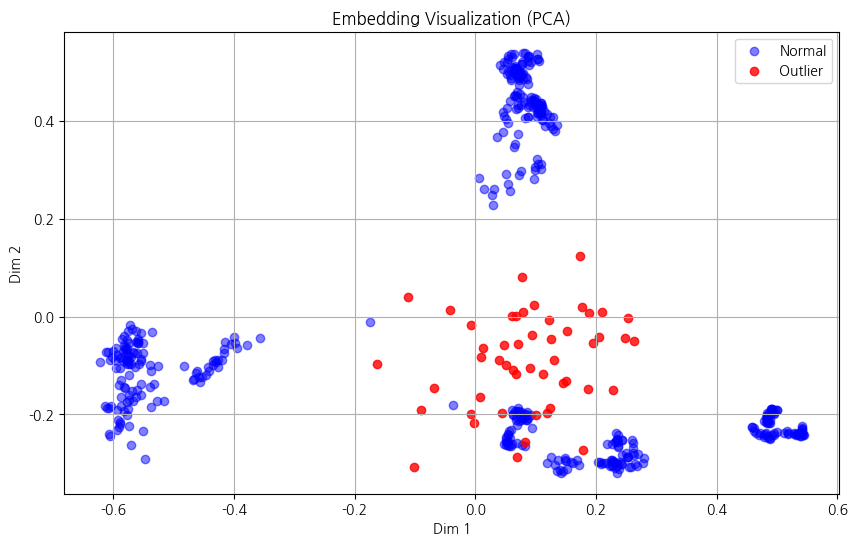

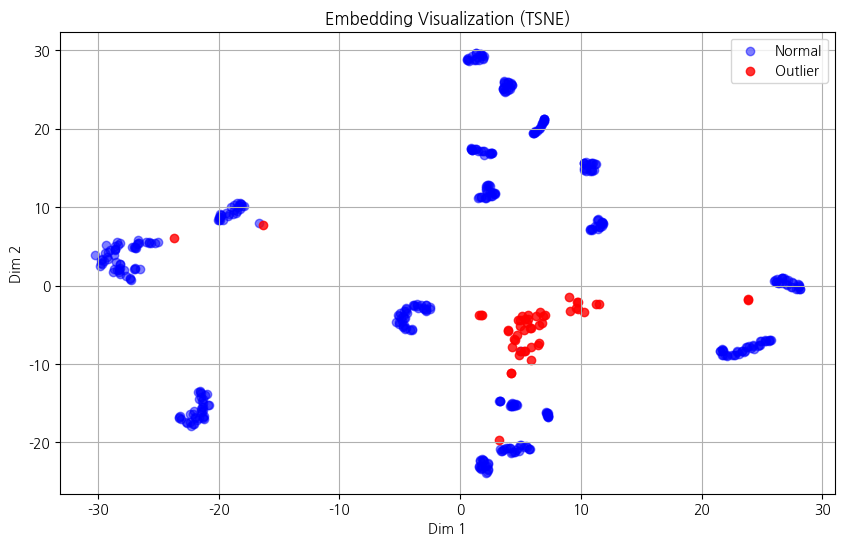

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torchvision.models import resnet18
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
import numpy as np
from PIL import Image

# -----------------------------
# 1. 이미지 임베딩 생성 (CNN)
# -----------------------------
class ImageEmbedder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        base_model = resnet18(pretrained=True)
        self.backbone = nn.Sequential(*list(base_model.children())[:-1])  # Remove FC
        self.projector = nn.Linear(512, embedding_dim)

    def forward(self, x):
        x = self.backbone(x).squeeze()
        return self.projector(x)

# -----------------------------
# 2. GCN 정의
# -----------------------------
class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = dropout_rate

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)

# -----------------------------
# 3. 이미지 불러오기 & 임베딩
# -----------------------------
def load_and_embed_images(folder, model, device):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])
    image_list = []
    embeddings = []
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        img = transform(Image.open(path).convert('RGB')).unsqueeze(0).to(device)
        with torch.no_grad():
            emb = model(img).cpu().numpy().squeeze()
            embeddings.append(emb)
            image_list.append(fname)
    return np.array(embeddings), image_list

# -----------------------------
# 4. 그래프 생성
# -----------------------------
def build_graph(features, k=5):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(features)
    distances, indices = nbrs.kneighbors(features)
    edge_index = []
    for i, neighbors in enumerate(indices):
        for j in neighbors[1:]:  # skip self-loop
            edge_index.append([i, j])
    edge_index = torch.tensor(edge_index).t().contiguous()
    return edge_index

# -----------------------------
# 5. 학습 및 이상치 계산
# -----------------------------
def detect_outliers(features, edge_index, hparams):
    x = torch.tensor(features, dtype=torch.float32).to(hparams['device'])
    edge_index = edge_index.to(hparams['device'])

    model = GCN(
        input_dim=x.shape[1],
        hidden_dim=hparams['gnn_hidden_dim'],
        output_dim=hparams['gnn_output_dim'],
        dropout_rate=hparams['dropout_rate']
    ).to(hparams['device'])

    optimizer = torch.optim.Adam(model.parameters(), lr=hparams['learning_rate'])

    model.train()
    for epoch in range(hparams['num_epochs']):
        optimizer.zero_grad()
        out = model(x, edge_index)
        loss = F.mse_loss(out, x)  # 자기 자신 복원
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        emb = model(x, edge_index).cpu().numpy()
    distances = np.linalg.norm(emb - features, axis=1)
    return distances

# -----------------------------
# 6. 시각화
# -----------------------------

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_embeddings(embeddings, outlier_scores, filenames, method="pca"):
    assert method in ["pca", "tsne"]

    # 이상치 기준
    threshold = np.percentile(outlier_scores, 90)
    is_outlier = outlier_scores > threshold

    # 차원 축소
    if method == "pca":
        reducer = PCA(n_components=2)
    else:
        reducer = TSNE(n_components=2, perplexity=30, init='pca', random_state=42)
    reduced = reducer.fit_transform(embeddings)

    # 시각화
    plt.figure(figsize=(10, 6))
    plt.scatter(reduced[~is_outlier, 0], reduced[~is_outlier, 1], c='blue', label='Normal', alpha=0.5)
    plt.scatter(reduced[is_outlier, 0], reduced[is_outlier, 1], c='red', label='Outlier', alpha=0.8)
    plt.legend()
    plt.title(f"Embedding Visualization ({method.upper()})")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.show()


# -----------------------------
# 7. 실행
# -----------------------------
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    hparams = {
        'embedding_dim': 128,
        'gnn_hidden_dim': 64,
        'gnn_output_dim': 128,
        'dropout_rate': 0.3,
        'num_epochs': 50,
        'learning_rate': 1e-3,
        'k_neighbors': 5,
        'device': device,
    }

    folder = 'images'
    embedder = ImageEmbedder(embedding_dim=hparams['embedding_dim']).to(device).eval()
    features, filenames = load_and_embed_images(folder, embedder, device)
    features = normalize(features)

    edge_index = build_graph(features, k=hparams['k_neighbors'])
    outlier_scores = detect_outliers(features, edge_index, hparams)

    # 상위 N% 이상치로 판별
    threshold = np.percentile(outlier_scores, 90)
    outliers = [fname for score, fname in zip(outlier_scores, filenames) if score > threshold]

    print("Detected outliers:")
    cnt = 0
    for fname in outliers:
        print(fname)
        cnt = cnt + 1
    print('total outlier: ', cnt)

    visualize_embeddings(features, outlier_scores, filenames, method="pca")
    visualize_embeddings(features, outlier_scores, filenames, method="tsne")


In [ ]:
!pip install torch torchvision
!pip install torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

## Edge Prediction

Epoch 10, Loss: 0.0000
Epoch 20, Loss: 0.0000
Epoch 30, Loss: 0.0000
Epoch 40, Loss: 0.0000
Epoch 50, Loss: 0.0000

📍 이상치로 분류된 이미지 목록:
 - 140_100.jpg
 - 141_100.jpg
 - 144_100.jpg
 - 145_100.jpg
 - 148_100.jpg
 - 149_100.jpg
 - 152_100.jpg
 - 153_100.jpg
 - 156_100.jpg
 - 157_100.jpg
 - 160_100.jpg
 - 161_100.jpg
 - 164_100.jpg
 - 165_100.jpg
 - 168_100.jpg
 - 169_100.jpg
 - 172_100.jpg
 - 173_100.jpg
 - 176_100.jpg
 - 177_100.jpg
 - 197_100.jpg
 - 200_100.jpg
 - 201_100.jpg
 - 204_100.jpg
 - 205_100.jpg
 - 208_100.jpg
 - 209_100.jpg
 - 20_100.jpg
 - 212_100.jpg
 - 213_100.jpg
 - 216_100.jpg
 - 21_100.jpg
 - 22_100.jpg
 - 23_100.jpg
 - 24_100.jpg
 - 25_100.jpg
 - 26_100.jpg
 - 27_100.jpg
 - 28_100.jpg
 - 29_100.jpg
 - 30_100.jpg
 - 31_100.jpg
 - 32_100.jpg
 - 33_100.jpg
 - 34_100.jpg
 - 35_100.jpg
 - 36_100.jpg
 - 37_100.jpg
 - 38_100.jpg
 - 39_100.jpg


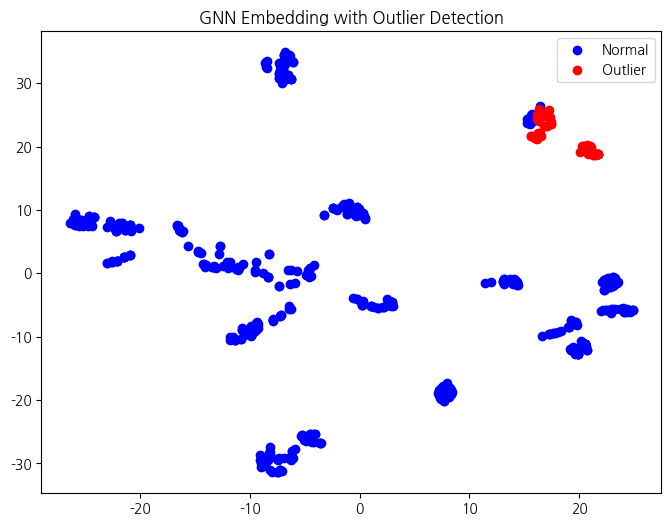

In [ ]:
import os
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torchvision import transforms
from torchvision.datasets.folder import default_loader
from tqdm import tqdm
import matplotlib.pyplot as plt

# ------------------------------------------
# 🔧 1. 하이퍼파라미터
# ------------------------------------------
params = {
    'image_folder': 'images',  # 이미지 폴더 경로
    'pca_dim': 64,
    'k': 8,
    'gnn_embedding_dim': 32,
    'gnn_hidden_dim': 64,
    'epochs': 50,
    'lr': 0.01,
    'outlier_ratio': 0.1,
    'image_size': 128,  # 이미지 resize 크기
}

# ------------------------------------------
# 🖼️ 2. 이미지 불러오기 및 임베딩
# ------------------------------------------
transform = transforms.Compose([
    transforms.Resize((params['image_size'], params['image_size'])),
    transforms.ToTensor(),
])

def load_images(folder):
    images, filenames = [], []
    for fname in sorted(os.listdir(folder)):
        path = os.path.join(folder, fname)
        try:
            img = default_loader(path)
            img = transform(img).view(-1).numpy()
            images.append(img)
            filenames.append(fname)
        except:
            continue
    return np.stack(images), filenames

X_raw, filenames = load_images(params['image_folder'])
pca = PCA(n_components=params['pca_dim'])
X = pca.fit_transform(X_raw)
X_tensor = torch.tensor(X, dtype=torch.float)

# ------------------------------------------
# 🔗 3. 그래프 생성 (k-NN 기반)
# ------------------------------------------
nbrs = NearestNeighbors(n_neighbors=params['k'] + 1).fit(X)
distances, indices = nbrs.kneighbors(X)

edges = []
for i in range(len(X)):
    for j in indices[i][1:]:
        edges.append((i, j))

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_label = torch.ones(edge_index.size(1))  # 양성 엣지

# ------------------------------------------
# 🚧 4. GNN 모델 정의
# ------------------------------------------
class GNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

model = GNN(params['pca_dim'], params['gnn_hidden_dim'], params['gnn_embedding_dim'])
optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])

# ------------------------------------------
# 🧠 5. Edge prediction 학습
# ------------------------------------------
model.train()
for epoch in range(params['epochs']):
    optimizer.zero_grad()
    z = model(X_tensor, edge_index)
    edge_sim = (z[edge_index[0]] * z[edge_index[1]]).sum(dim=1)
    loss = F.binary_cross_entropy_with_logits(edge_sim, edge_label)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ------------------------------------------
# 📉 6. 이상치 탐지 (연결성 기반)
# ------------------------------------------
model.eval()
with torch.no_grad():
    z = model(X_tensor, edge_index)
    sim_matrix = torch.matmul(z, z.T)

# 각 노드의 평균 연결 점수 계산
avg_scores = sim_matrix.mean(dim=1).cpu().numpy()
threshold = np.percentile(avg_scores, 100 * params['outlier_ratio'])
outlier_mask = avg_scores <= threshold

# ------------------------------------------
# 📋 7. 결과 출력
# ------------------------------------------
print("\n📍 이상치로 분류된 이미지 목록:")
for i, is_outlier in enumerate(outlier_mask):
    if is_outlier:
        print(f" - {filenames[i]}")

# ------------------------------------------
# 📊 8. 시각화 (2D)
# ------------------------------------------
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_embedded = tsne.fit_transform(z.cpu().numpy())

plt.figure(figsize=(8,6))
plt.scatter(X_embedded[~outlier_mask, 0], X_embedded[~outlier_mask, 1], c='blue', label='Normal')
plt.scatter(X_embedded[outlier_mask, 0], X_embedded[outlier_mask, 1], c='red', label='Outlier')
plt.legend()
plt.title("GNN Embedding with Outlier Detection")
plt.show()


In [ ]:
import os
from PIL import Image

def overlay_images(img1, img2, alpha=0.5):
    img2 = img2.resize(img1.size)
    return Image.blend(img1, img2, alpha)

def sequential_overlay_folder(folder_path, alpha=0.5):
    files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('png','jpg','jpeg','bmp'))])
    if len(files) < 2:
        print("이미지가 2장 이상 필요합니다.")
        return

    for i in range(len(files) - 1):
        path1 = os.path.join(folder_path, files[i])
        path2 = os.path.join(folder_path, files[i+1])

        img1 = Image.open(path1).convert("RGBA")
        img2 = Image.open(path2).convert("RGBA")

        blended = overlay_images(img1, img2, alpha)
        blended.show(title=f"Overlay: {files[i]} + {files[i+1]}")

        input("다음 이미지 겹침을 보려면 엔터 키를 누르세요...")

# 사용 예시
folder = "images




"  # 실제 이미지 폴더 경로로 변경하세요
sequential_overlay_folder(folder, alpha=0.5)


다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...
다음 이미지 겹침을 보려면 엔터 키를 누르세요...


KeyboardInterrupt: Interrupted by user

## GNN(GCN, GraphSADE...)
- One image to one graph
- Embedding by GNN
- Clustering with K-nn

### Normal pixel

In [ ]:
import os
import torch
import torchvision.transforms as T
from torchvision.io import read_image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import pairwise_distances
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, SAGEConv, global_mean_pool

# --- 하이퍼파라미터 ---
IMG_SIZE = 64               # 이미지 resize 크기
NUM_SAMPLE_PIXELS = 500     # 이미지 당 노드(픽셀) 개수 샘플링
BATCH_SIZE = 8
EMBEDDING_DIM = 64
EPOCHS = 20
LR = 0.01

# --- 이미지 -> 그래프 변환 함수 ---
def image_to_graph(img_tensor, num_nodes=NUM_SAMPLE_PIXELS):
    """
    img_tensor: [3, H, W] RGB 이미지 텐서
    - 노드: 랜덤 샘플링한 픽셀
    - 노드 특징: RGB (3차원)
    - 엣지: k-NN (근처 픽셀과 연결)
    """
    C, H, W = img_tensor.shape
    img_flat = img_tensor.view(C, -1).T  # (H*W, 3)

    # 랜덤 샘플링 픽셀 인덱스
    idx = torch.randperm(H*W)[:num_nodes]
    nodes_feat = img_flat[idx] / 255.0  # 정규화 RGB

    # 좌표 (x,y) for k-NN edge 생성
    coords = torch.stack([idx // W, idx % W], dim=1).float()

    # 간단하게 각 노드의 8방향 인접 노드 연결
    # 이론적으로 k-NN (예: sklearn.neighbors) 써도 됨, 여기선 거리 기준 연결
    edge_index = []
    for i in range(num_nodes):
        for j in range(i+1, num_nodes):
            dist = torch.norm(coords[i] - coords[j])
            if dist < 10:  # 픽셀 거리 10 이하만 연결 (하이퍼파라미터)
                edge_index.append([i,j])
                edge_index.append([j,i])
    if len(edge_index) == 0:
        # 연결 없으면 임의로 연결 추가 (전체 연결)
        for i in range(num_nodes-1):
            edge_index.append([i, i+1])
            edge_index.append([i+1, i])
    edge_index = torch.tensor(edge_index).t().contiguous()

    data = Data(x=nodes_feat, edge_index=edge_index)
    return data

# --- GNN 모델 클래스들 ---
class GCN(torch.nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, out_dim=64):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        x = global_mean_pool(x, batch)
        return x

class GraphSAGE(torch.nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, out_dim=64):
        super().__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        x = global_mean_pool(x, batch)
        return x

# --- 이미지 폴더 로딩 및 그래프 생성 ---
def load_dataset(folder_path):
    files = [f for f in os.listdir(folder_path) if f.endswith(('.png','.jpg','.jpeg'))]
    graphs = []
    for f in files:
        img = read_image(os.path.join(folder_path, f))
        # 리사이즈
        img = T.Resize((IMG_SIZE, IMG_SIZE))(img)
        graph = image_to_graph(img)
        graph.img_name = f
        graphs.append(graph)
    return graphs

# --- 학습 함수 (임베딩 학습) ---
def train_gnn(model, data_loader, epochs=EPOCHS):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for data in data_loader:
            optimizer.zero_grad()
            embeddings = model(data)
            # 여기선 임베딩만 뽑고, 지도 학습 없으므로 최소화는 하지 않음.
            # 단순 임베딩 학습으로 대체하려면 자기지도 학습 추가 필요
            # (여기선 간단하게 학습하지 않고 바로 임베딩 사용)
            loss = embeddings.norm() * 0  # dummy loss 0
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

# --- 임베딩 추출 함수 ---
def get_embeddings(model, data_loader):
    model.eval()
    embeddings = []
    img_names = []
    with torch.no_grad():
        for data in data_loader:
            emb = model(data)
            embeddings.append(emb)
            img_names.extend(data.img_name if hasattr(data, 'img_name') else [])
    embeddings = torch.cat(embeddings, dim=0)
    return embeddings, img_names

# --- 이상치 후보 찾기 ---
def find_outliers(embeddings, top_k=3):
    # 거리 행렬 계산 (유클리드)
    dist_matrix = pairwise_distances(embeddings.cpu(), metric='euclidean')
    # 각 이미지의 평균 거리 계산
    mean_dists = dist_matrix.mean(axis=1)
    # 거리 큰 순서로 이상치 후보 추출
    outlier_indices = np.argsort(-mean_dists)[:top_k]
    return outlier_indices, mean_dists

# --- 시각화 ---
def visualize_results(folder_path, img_names, outlier_indices):
    plt.figure(figsize=(15,5))
    for i, idx in enumerate(outlier_indices):
        img = plt.imread(os.path.join(folder_path, img_names[idx]))
        plt.subplot(1,len(outlier_indices), i+1)
        plt.imshow(img)
        plt.title(f"Outlier #{i+1}")
        plt.axis('off')
    plt.show()

# --- 메인 실행 ---
def main():
    folder_path = "imgData/mini_final"  # 이미지 폴더 경로

    graphs = load_dataset(folder_path)
    print(f"Loaded {len(graphs)} graphs from images.")

    # DataLoader 준비
    for g in graphs:
        g.img_name = [g.img_name]  # DataLoader batch를 위해 리스트로 감싸기
    loader = DataLoader(graphs, batch_size=BATCH_SIZE)

    # 여러 GNN 모델 평가
    models = {
        "GCN": GCN(),
        "GraphSAGE": GraphSAGE(),
    }

    all_embeddings = {}
    for name, model in models.items():
        print(f"Training {name}...")
        train_gnn(model, loader)
        embeddings, img_names = get_embeddings(model, loader)
        all_embeddings[name] = (embeddings, img_names)

    # 이상치 후보 찾기 및 시각화
    for name, (embeddings, img_names) in all_embeddings.items():
        print(f"Finding outliers using {name} embeddings...")
        outlier_idx, mean_dists = find_outliers(embeddings)
        print(f"Top outliers: {[img_names[i] for i in outlier_idx]}")
        visualize_results(folder_path, img_names, outlier_idx)

if __name__ == "__main__":
    main()


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-9-0c078abdcf0f>", line 179, in <cell line: 0>
    main()
  File "<ipython-input-9-0c078abdcf0f>", line 150, in main
    graphs = load_dataset(folder_path)
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-9-0c078abdcf0f>", line 89, in load_dataset
    graph = image_to_graph(img)
            ^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-9-0c078abdcf0f>", line None, in image_to_graph
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
          ^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'KeyboardInterrupt' object has no attribute '_render_traceback_'



### Superpixel

In [ ]:
import os
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, SAGEConv, global_mean_pool
from torchvision.io import read_image
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np
from skimage.segmentation import slic
from skimage.util import img_as_float
import warnings

warnings.filterwarnings("ignore")

# 이미지 → superpixel 그래프 변환
def image_to_graph_superpixel(image, num_segments=75):
    image = image / 255.0
    image_np = image.permute(1, 2, 0).numpy()
    image_float = img_as_float(image_np)
    segments = slic(image_float, n_segments=num_segments, compactness=10, sigma=1, start_label=0)
    segments = torch.tensor(segments)

    H, W = segments.shape
    num_nodes = segments.max().item() + 1
    x = torch.zeros((num_nodes, 3), dtype=torch.float32)
    counts = torch.zeros(num_nodes, dtype=torch.float32)

    for y in range(H):
        for x_ in range(W):
            seg_id = segments[y, x_].item()
            x[seg_id] += image[:, y, x_]
            counts[seg_id] += 1

    counts[counts == 0] = 1
    x = x / counts.unsqueeze(1)

    edges = set()
    for y in range(H - 1):
        for x_ in range(W - 1):
            cur = segments[y, x_].item()
            right = segments[y, x_ + 1].item()
            down = segments[y + 1, x_].item()
            if cur != right:
                edges.add((cur, right))
                edges.add((right, cur))
            if cur != down:
                edges.add((cur, down))
                edges.add((down, cur))

    edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)

# 이미지 폴더에서 그래프 불러오기
def load_graphs_from_images_superpixel(image_folder, num_segments=75):
    graphs = []
    image_names = []
    transform = transforms.Compose([transforms.Resize((64, 64))])
    image_files = sorted([f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    print(f"총 {len(image_files)}개의 이미지를 처리합니다...")

    for image_name in tqdm(image_files, desc="superpixel 그래프 생성 중"):
        image_path = os.path.join(image_folder, image_name)
        image = read_image(image_path)
        image = transform(image)
        graph = image_to_graph_superpixel(image, num_segments=num_segments)
        graph.image_name = image_name
        graphs.append(graph)
        image_names.append(image_name)

    return graphs, image_names

# GNN 모델 정의
class GNNEncoder(torch.nn.Module):
    def __init__(self, model_type='GCN', in_channels=3, hidden_channels=64, out_channels=32):
        super().__init__()
        if model_type == 'GCN':
            self.conv1 = GCNConv(in_channels, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, out_channels)
        elif model_type == 'GraphSAGE':
            self.conv1 = SAGEConv(in_channels, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, out_channels)
        else:
            raise ValueError("지원되지 않는 GNN 모델입니다: GCN 또는 GraphSAGE 사용")

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        x = global_mean_pool(x, batch)
        return x

# 임베딩 생성
def extract_embeddings(graphs, model_type='GCN'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GNNEncoder(model_type=model_type).to(device)
    model.eval()

    loader = Batch.from_data_list(graphs).to(device)
    with torch.no_grad():
        emb = model(loader.x, loader.edge_index, loader.batch)
    return emb.cpu().numpy()

# 이상치 탐지
def detect_outliers(embeddings, image_names, top_k=5):
    dists = euclidean_distances(embeddings)
    mean_dists = dists.mean(axis=1)
    outlier_indices = np.argsort(mean_dists)[-top_k:]
    return [image_names[i] for i in outlier_indices], mean_dists, outlier_indices

# 시각화
def visualize_embeddings(embeddings, outlier_indices, title):
    reduced = TSNE(n_components=2, perplexity=10, random_state=42).fit_transform(embeddings)
    plt.figure(figsize=(8, 6))
    plt.scatter(reduced[:, 0], reduced[:, 1], c='gray', label='Normal')
    plt.scatter(reduced[outlier_indices, 0], reduced[outlier_indices, 1], c='red', label='Outliers')
    plt.title(title)
    plt.legend()
    plt.show()

# 전체 실행 파이프라인
def run_pipeline_superpixel(image_folder, num_segments=75, top_k=5):
    graphs, image_names = load_graphs_from_images_superpixel(image_folder, num_segments=num_segments)

    for model_type in ['GCN', 'GraphSAGE']:
        print(f"\n {model_type} 기반 GNN 임베딩 생성 중...")
        embeddings = extract_embeddings(graphs, model_type=model_type)
        outliers, mean_dists, outlier_indices = detect_outliers(embeddings, image_names, top_k=top_k)
        print(f"이상치 이미지 ({model_type}): {outliers}")
        visualize_embeddings(embeddings, outlier_indices, title=f"{model_type} 임베딩 시각화 (이상치 강조)")

# 실행 코드
if __name__ == "__main__":
    image_folder = "images"  # 여기 이미지 폴더 경로 넣으세요
    run_pipeline_superpixel(image_folder=image_folder, num_segments=75, top_k=52)


ModuleNotFoundError: No module named 'torch_geometric'

In [ ]:
pip install --upgrade scikit-image

In [ ]:
pip install torch torchvision torch-geometric scikit-image matplotlib scikit-learn

In [ ]:
import os
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torchvision import transforms
from PIL import Image
import numpy as np
from skimage.segmentation import slic
from skimage.future import graph
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 하이퍼파라미터 설정
config = {
    "image_dir": "./images",
    "num_segments": 75,
    "compactness": 10,
    "sigma": 1,
    "image_resize": (64, 64),
    "model_types": ["GCN", "GraphSAGE", "GAT", "GraphConv"],  # 여러 모델 리스트
    "hidden_channels": 64,
    "out_channels": 32,
    "top_k": 5,
    "tsne_perplexity": 15,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

# 이미지 -> 그래프 변환
def image_to_graph_superpixel(image_path, config):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize(config["image_resize"]),
    ])
    image = transform(image)
    img_np = np.array(image)

    segments = slic(
        img_np,
        n_segments=config["num_segments"],
        compactness=config["compactness"],
        sigma=config["sigma"],
        start_label=0
    )

    rag = graph.rag_mean_color(img_np, segments)
    num_nodes = len(np.unique(segments))
    features = np.zeros((num_nodes, 3), dtype=np.float32)

    for i in range(num_nodes):
        mask = (segments == i)
        features[i] = img_np[mask].mean(axis=0) / 255.0

    edge_index = []
    for n1, n2 in rag.edges:
        edge_index.append([n1, n2])
        edge_index.append([n2, n1])
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    x = torch.tensor(features, dtype=torch.float)

    return Data(x=x, edge_index=edge_index)

# 전체 데이터셋 불러오기
def load_graphs_from_images_superpixel(image_dir, config):
    data_list = []
    image_names = []
    for filename in os.listdir(image_dir):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            path = os.path.join(image_dir, filename)
            data = image_to_graph_superpixel(path, config)
            data_list.append(data)
            image_names.append(filename)
    return data_list, image_names

# GNN 모델 클래스 (여러 모델 지원)
class GNNEncoder(torch.nn.Module):
    def __init__(self, model_type, config):
        super().__init__()
        in_channels = 3
        hidden_channels = config["hidden_channels"]
        out_channels = config["out_channels"]
        self.model_type = model_type

        if model_type == "GCN":
            self.conv1 = GCNConv(in_channels, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, out_channels)
        elif model_type == "GraphSAGE":
            self.conv1 = SAGEConv(in_channels, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, out_channels)
        elif model_type == "GAT":
            self.conv1 = GATConv(in_channels, hidden_channels, heads=4, concat=True)
            self.conv2 = GATConv(hidden_channels*4, out_channels, heads=1, concat=False)
        elif model_type == "GraphConv":
            self.conv1 = GraphConv(in_channels, hidden_channels)
            self.conv2 = GraphConv(hidden_channels, out_channels)
        else:
            raise ValueError(f"Unsupported model type: {model_type}")

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        # 그래프 단위 임베딩: 노드 임베딩 평균
        x = torch.mean(x, dim=0)
        return x

# 임베딩 추출
def extract_embeddings(data_list, model, config):
    model.eval()
    embeddings = []
    device = config["device"]
    model.to(device)
    with torch.no_grad():
        for data in data_list:
            data = data.to(device)
            emb = model(data)
            embeddings.append(emb.cpu().numpy())
    embeddings = np.stack(embeddings)
    return embeddings

# 이상치 탐지
def detect_outliers(embeddings, top_k):
    dist_matrix = pairwise_distances(embeddings, metric='euclidean')
    mean_dist = (dist_matrix.sum(axis=1) - 0) / (dist_matrix.shape[0] - 1)
    outlier_indices = np.argsort(mean_dist)[::-1][:top_k]
    return outlier_indices, mean_dist

# 시각화
def visualize_embeddings(embeddings, outlier_indices, image_names, model_name, config):
    tsne = TSNE(n_components=2, perplexity=config["tsne_perplexity"], random_state=42)
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10,7))
    plt.scatter(emb_2d[:,0], emb_2d[:,1], c='blue', label='Normal')
    plt.scatter(emb_2d[outlier_indices,0], emb_2d[outlier_indices,1], c='red', label='Outliers')
    for i in outlier_indices:
        plt.annotate(image_names[i], (emb_2d[i,0], emb_2d[i,1]), color='red')
    plt.legend()
    plt.title(f"GNN Embedding Visualization ({model_name})")
    plt.show()

# 전체 실행
def run_pipeline_all_models(config):
    print("1) 이미지 -> 그래프 변환 중...")
    data_list, image_names = load_graphs_from_images_superpixel(config["image_dir"], config)
    print(f"총 {len(data_list)}개의 그래프를 불러왔습니다.\n")

    for model_name in config["model_types"]:
        print(f"=== 모델: {model_name} ===")
        model = GNNEncoder(model_name, config)
        embeddings = extract_embeddings(data_list, model, config)
        outlier_indices, mean_dist = detect_outliers(embeddings, config["top_k"])

        print(f"이상치 후보 (top {config['top_k']}):")
        for idx in outlier_indices:
            print(f" - {image_names[idx]} (평균 거리: {mean_dist[idx]:.4f})")
        visualize_embeddings(embeddings, outlier_indices, image_names, model_name, config)
        print("\n")


run_pipeline_all_models(config)


ModuleNotFoundError: No module named 'torch_geometric'

## GCN, GraphSADE, GAT, GraphConv

1) 이미지 -> 그래프 변환 중...
총 500개의 그래프를 불러왔습니다.

=== 모델: GCN ===
이상치 후보 (top 50):
 - 000000001359.jpg (평균 거리: 0.3938)
 - 000000001407.jpg (평균 거리: 0.3928)
 - 000000000025.jpg (평균 거리: 0.3897)
 - 000000001488.jpg (평균 거리: 0.3858)
 - 000000001390.jpg (평균 거리: 0.3830)
 - r0_5_100.jpg (평균 거리: 0.3824)
 - r0_1_100.jpg (평균 거리: 0.3812)
 - r0_0_100.jpg (평균 거리: 0.3807)
 - r0_2_100.jpg (평균 거리: 0.3789)
 - r0_3_100.jpg (평균 거리: 0.3768)
 - 000000001330.jpg (평균 거리: 0.3748)
 - r0_8_100.jpg (평균 거리: 0.3742)
 - r0_13_100.jpg (평균 거리: 0.3733)
 - r0_7_100.jpg (평균 거리: 0.3733)
 - 000000001340.jpg (평균 거리: 0.3730)
 - r0_6_100.jpg (평균 거리: 0.3720)
 - r0_19_100.jpg (평균 거리: 0.3717)
 - r0_9_100.jpg (평균 거리: 0.3699)
 - r0_4_100.jpg (평균 거리: 0.3678)
 - r0_11_100.jpg (평균 거리: 0.3671)
 - r0_16_100.jpg (평균 거리: 0.3659)
 - r0_12_100.jpg (평균 거리: 0.3654)
 - r0_14_100.jpg (평균 거리: 0.3652)
 - 000000001397.jpg (평균 거리: 0.3651)
 - r0_17_100.jpg (평균 거리: 0.3648)
 - r0_10_100.jpg (평균 거리: 0.3632)
 - r0_18_100.jpg (평균 거리: 0.3630)
 - r0_15_100.jpg (

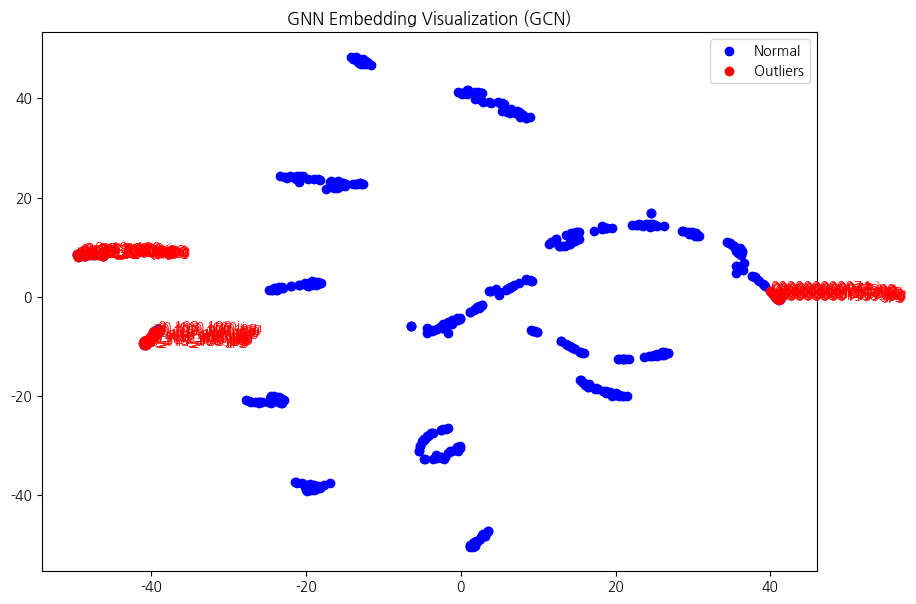



=== 모델: GraphSAGE ===
이상치 후보 (top 50):
 - 000000001407.jpg (평균 거리: 0.7074)
 - 000000001359.jpg (평균 거리: 0.7065)
 - 000000000025.jpg (평균 거리: 0.6957)
 - 000000001488.jpg (평균 거리: 0.6946)
 - 000000001390.jpg (평균 거리: 0.6892)
 - 000000001330.jpg (평균 거리: 0.6798)
 - 000000001340.jpg (평균 거리: 0.6730)
 - r0_1_100.jpg (평균 거리: 0.6661)
 - r0_0_100.jpg (평균 거리: 0.6627)
 - r0_5_100.jpg (평균 거리: 0.6620)
 - 000000001397.jpg (평균 거리: 0.6589)
 - r0_3_100.jpg (평균 거리: 0.6578)
 - r0_2_100.jpg (평균 거리: 0.6553)
 - r0_8_100.jpg (평균 거리: 0.6498)
 - r0_7_100.jpg (평균 거리: 0.6486)
 - r0_13_100.jpg (평균 거리: 0.6486)
 - r0_6_100.jpg (평균 거리: 0.6469)
 - 000000000049.jpg (평균 거리: 0.6453)
 - 000000001375.jpg (평균 거리: 0.6449)
 - r0_19_100.jpg (평균 거리: 0.6405)
 - 000000000077.jpg (평균 거리: 0.6398)
 - r0_4_100.jpg (평균 거리: 0.6390)
 - r0_9_100.jpg (평균 거리: 0.6385)
 - r0_11_100.jpg (평균 거리: 0.6369)
 - r0_12_100.jpg (평균 거리: 0.6361)
 - r0_16_100.jpg (평균 거리: 0.6336)
 - r0_10_100.jpg (평균 거리: 0.6325)
 - r0_18_100.jpg (평균 거리: 0.6320)
 - r0_14_100

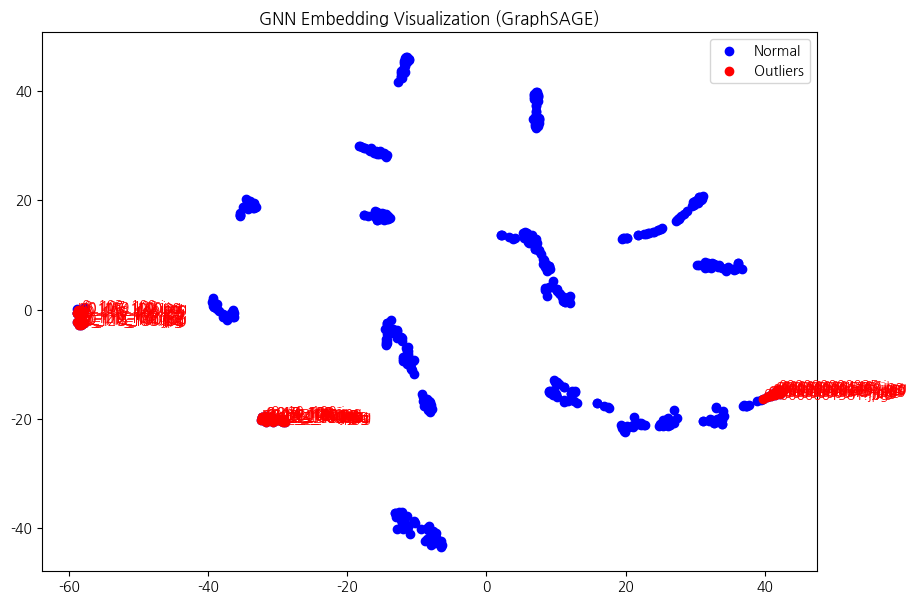



=== 모델: GAT ===
이상치 후보 (top 50):
 - 000000001359.jpg (평균 거리: 0.2331)
 - 000000001407.jpg (평균 거리: 0.2331)
 - 000000001488.jpg (평균 거리: 0.2298)
 - 000000000025.jpg (평균 거리: 0.2297)
 - 000000001390.jpg (평균 거리: 0.2280)
 - 000000001330.jpg (평균 거리: 0.2248)
 - 000000001340.jpg (평균 거리: 0.2227)
 - 000000001397.jpg (평균 거리: 0.2197)
 - 000000001375.jpg (평균 거리: 0.2152)
 - r0_1_100.jpg (평균 거리: 0.2145)
 - 000000000049.jpg (평균 거리: 0.2139)
 - r0_0_100.jpg (평균 거리: 0.2134)
 - r0_5_100.jpg (평균 거리: 0.2134)
 - 000000000077.jpg (평균 거리: 0.2117)
 - r0_2_100.jpg (평균 거리: 0.2116)
 - r0_3_100.jpg (평균 거리: 0.2115)
 - 000000000042.jpg (평균 거리: 0.2095)
 - r0_8_100.jpg (평균 거리: 0.2091)
 - r0_13_100.jpg (평균 거리: 0.2090)
 - r0_7_100.jpg (평균 거리: 0.2084)
 - r0_6_100.jpg (평균 거리: 0.2081)
 - r0_19_100.jpg (평균 거리: 0.2067)
 - r0_4_100.jpg (평균 거리: 0.2052)
 - r0_9_100.jpg (평균 거리: 0.2052)
 - r0_12_100.jpg (평균 거리: 0.2046)
 - r0_11_100.jpg (평균 거리: 0.2043)
 - 000000000074.jpg (평균 거리: 0.2043)
 - r0_16_100.jpg (평균 거리: 0.2041)
 - r0_14_100

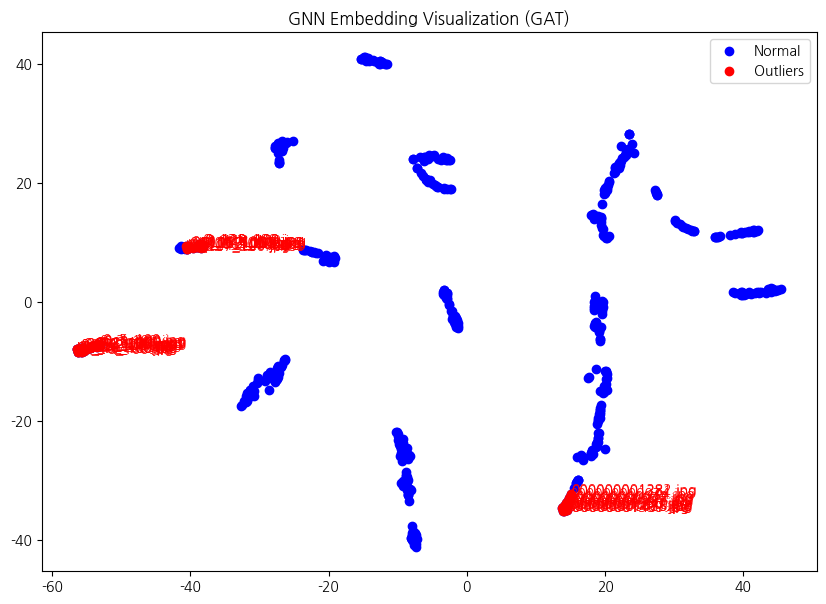



=== 모델: GraphConv ===
이상치 후보 (top 50):
 - 000000000025.jpg (평균 거리: 25.8021)
 - 000000001359.jpg (평균 거리: 25.6118)
 - 000000001340.jpg (평균 거리: 24.5157)
 - 000000000074.jpg (평균 거리: 24.3597)
 - 000000001488.jpg (평균 거리: 23.2423)
 - 000000001390.jpg (평균 거리: 23.2105)
 - 000000001330.jpg (평균 거리: 22.4797)
 - 000000001407.jpg (평균 거리: 21.6196)
 - 000000000049.jpg (평균 거리: 21.3387)
 - 000000001375.jpg (평균 거리: 21.1873)
 - 000000001397.jpg (평균 거리: 20.9823)
 - 000000001386.jpg (평균 거리: 19.6411)
 - 000000001381.jpg (평균 거리: 19.3790)
 - 000000000042.jpg (평균 거리: 19.2953)
 - 000000000077.jpg (평균 거리: 18.7163)
 - r0_175_100.jpg (평균 거리: 18.1241)
 - r0_177_100.jpg (평균 거리: 18.0846)
 - 000000001355.jpg (평균 거리: 17.9320)
 - 000000000086.jpg (평균 거리: 17.7671)
 - r0_179_100.jpg (평균 거리: 17.3650)
 - r0_176_100.jpg (평균 거리: 17.1948)
 - r0_171_100.jpg (평균 거리: 17.1038)
 - r0_181_100.jpg (평균 거리: 17.0682)
 - r0_178_100.jpg (평균 거리: 16.9832)
 - r0_173_100.jpg (평균 거리: 16.9046)
 - r0_174_100.jpg (평균 거리: 16.8390)
 - r0_184_100.j

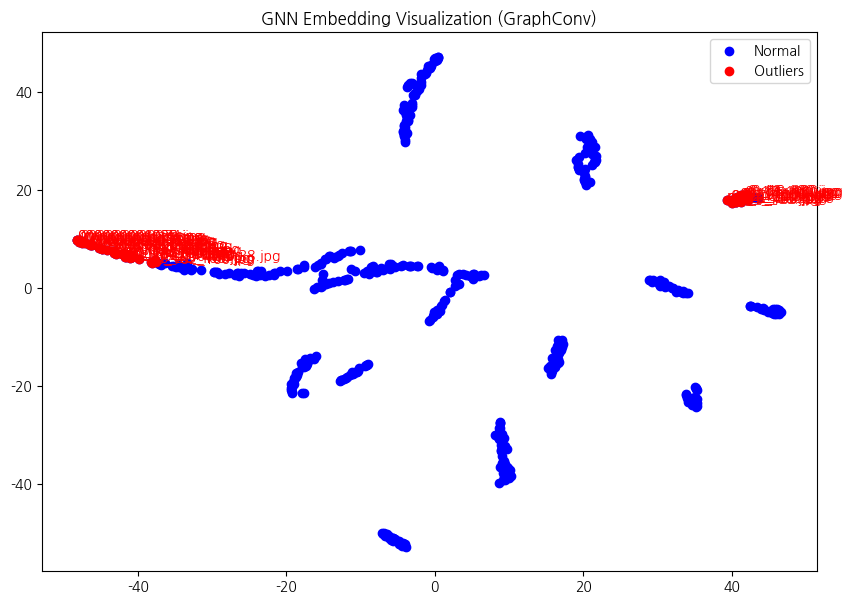

In [ ]:
import os
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torchvision import transforms
from PIL import Image
import numpy as np
from skimage.segmentation import slic
from skimage import graph
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 이미지 -> 그래프 변환
def image_to_graph_superpixel(image_path, config):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize(config["image_resize"]),
    ])
    image = transform(image)
    img_np = np.array(image)

    segments = slic(
        img_np,
        n_segments=config["num_segments"],
        compactness=config["compactness"],
        sigma=config["sigma"],
        start_label=0
    )

    rag = graph.rag_mean_color(img_np, segments)
    num_nodes = len(np.unique(segments))
    features = np.zeros((num_nodes, 3), dtype=np.float32)

    for i in range(num_nodes):
        mask = (segments == i)
        features[i] = img_np[mask].mean(axis=0) / 255.0

    edge_index = []
    for n1, n2 in rag.edges:
        edge_index.append([n1, n2])
        edge_index.append([n2, n1])
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    x = torch.tensor(features, dtype=torch.float)

    return Data(x=x, edge_index=edge_index)

# 전체 데이터셋 불러오기
def load_graphs_from_images_superpixel(image_dir, config):
    data_list = []
    image_names = []
    for filename in os.listdir(image_dir):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            path = os.path.join(image_dir, filename)
            data = image_to_graph_superpixel(path, config)
            data_list.append(data)
            image_names.append(filename)
    return data_list, image_names

# GNN 모델 클래스 (GCN, GraphSAGE, GAT, GraphConv)
class GNNEncoder(torch.nn.Module):
    def __init__(self, model_type, config):
        super().__init__()
        in_channels = 3
        hidden_channels = config["hidden_channels"]
        out_channels = config["out_channels"]
        self.model_type = model_type

        if model_type == "GCN":
            self.conv1 = GCNConv(in_channels, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, out_channels)
        elif model_type == "GraphSAGE":
            self.conv1 = SAGEConv(in_channels, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, out_channels)
        elif model_type == "GAT":
            self.conv1 = GATConv(in_channels, hidden_channels, heads=4, concat=True)
            self.conv2 = GATConv(hidden_channels*4, out_channels, heads=1, concat=False)
        elif model_type == "GraphConv":
            self.conv1 = GraphConv(in_channels, hidden_channels)
            self.conv2 = GraphConv(hidden_channels, out_channels)
        else:
            raise ValueError(f"Unsupported model type: {model_type}")

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        # 그래프 단위 임베딩: 노드 임베딩 평균
        x = torch.mean(x, dim=0)
        return x

# 임베딩 추출
def extract_embeddings(data_list, model, config):
    model.eval()
    embeddings = []
    device = config["device"]
    model.to(device)
    with torch.no_grad():
        for data in data_list:
            data = data.to(device)
            emb = model(data)
            embeddings.append(emb.cpu().numpy())
    embeddings = np.stack(embeddings)
    return embeddings

# 이상치 탐지
def detect_outliers(embeddings, top_k):
    dist_matrix = pairwise_distances(embeddings, metric='euclidean')
    mean_dist = (dist_matrix.sum(axis=1) - 0) / (dist_matrix.shape[0] - 1)
    outlier_indices = np.argsort(mean_dist)[::-1][:top_k]
    return outlier_indices, mean_dist

# 시각화
def visualize_embeddings(embeddings, outlier_indices, image_names, model_name, config):
    tsne = TSNE(n_components=2, perplexity=config["tsne_perplexity"], random_state=42)
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10,7))
    plt.scatter(emb_2d[:,0], emb_2d[:,1], c='blue', label='Normal')
    plt.scatter(emb_2d[outlier_indices,0], emb_2d[outlier_indices,1], c='red', label='Outliers')
    for i in outlier_indices:
        plt.annotate(image_names[i], (emb_2d[i,0], emb_2d[i,1]), color='red')
    plt.legend()
    plt.title(f"GNN Embedding Visualization ({model_name})")
    plt.show()

# 전체 실행
def run_pipeline_all_models(config):
    print("1) 이미지 -> 그래프 변환 중...")
    data_list, image_names = load_graphs_from_images_superpixel(config["image_dir"], config)
    print(f"총 {len(data_list)}개의 그래프를 불러왔습니다.\n")

    for model_name in config["model_types"]:
        print(f"=== 모델: {model_name} ===")
        model = GNNEncoder(model_name, config)
        embeddings = extract_embeddings(data_list, model, config)
        outlier_indices, mean_dist = detect_outliers(embeddings, config["top_k"])

        print(f"이상치 후보 (top {config['top_k']}):")
        for idx in outlier_indices:
            print(f" - {image_names[idx]} (평균 거리: {mean_dist[idx]:.4f})")
        visualize_embeddings(embeddings, outlier_indices, image_names, model_name, config)
        print("\n")

config = {
    "image_dir": "images",
    "num_segments": 128,
    "compactness": 10,
    "sigma": 1,
    "image_resize": (128, 128),
    "model_types": ["GCN", "GraphSAGE", "GAT", "GraphConv"],  # 여러 모델 리스트
    "hidden_channels": 64,
    "out_channels": 32,
    "top_k": 50,
    "tsne_perplexity": 15,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}
run_pipeline_all_models(config)


In [ ]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.io import read_image
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
from skimage.segmentation import slic
from tqdm import tqdm

# ----------------------- Config -----------------------
config = {
    'num_segments': 75,
    'gnn_models': ['GCN', 'GraphSAGE', 'GAT', 'GraphConv'],
    'embedding_dim': 32,
    'epochs': 50,
    'lr': 0.01,
    'dbscan_eps': 2.5,
    'dbscan_min_samples': 3,
    'agglomerative_threshold': 5.0,
    'cluster_methods': ['DBSCAN', 'Agglomerative'],
}

# ----------------------- GNN Models -----------------------
class GNNModel(torch.nn.Module):
    def __init__(self, in_channels, out_channels, model_type='GCN'):
        super().__init__()
        if model_type == 'GCN':
            self.conv1 = GCNConv(in_channels, 64)
            self.conv2 = GCNConv(64, out_channels)
        elif model_type == 'GraphSAGE':
            self.conv1 = SAGEConv(in_channels, 64)
            self.conv2 = SAGEConv(64, out_channels)
        elif model_type == 'GAT':
            self.conv1 = GATConv(in_channels, 64, heads=2, concat=False)
            self.conv2 = GATConv(64, out_channels, heads=2, concat=False)
        elif model_type == 'GraphConv':
            self.conv1 = GraphConv(in_channels, 64)
            self.conv2 = GraphConv(64, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# ----------------------- Data Processing -----------------------
def image_to_graph(image_path):
    img = read_image(image_path).float() / 255.0
    img = img.permute(1, 2, 0).numpy()  # HWC
    segments = slic(img, n_segments=config['num_segments'], compactness=10)

    features = []
    positions = []
    for seg_val in np.unique(segments):
        mask = segments == seg_val
        rgb = img[mask].mean(axis=0)
        pos = np.argwhere(mask).mean(axis=0)
        features.append(rgb)
        positions.append(pos)

    features = torch.tensor(features, dtype=torch.float)
    positions = torch.tensor(positions, dtype=torch.float)
    edge_index = []
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=6).fit(positions)
    _, indices = nn.kneighbors(positions)
    for i, neighbors in enumerate(indices):
        for j in neighbors:
            if i != j:
                edge_index.append([i, j])
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    return Data(x=features, edge_index=edge_index)

# ----------------------- Main Pipeline -----------------------
def main(image_folder):
    image_paths = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.png', '.jpg'))]
    image_paths.sort()
    graphs = []
    print("Converting images to graphs...")
    for path in tqdm(image_paths):
        graphs.append(image_to_graph(path))

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    for model_type in config['gnn_models']:
        print(f"\n--- GNN Model: {model_type} ---")
        model = GNNModel(in_channels=3, out_channels=config['embedding_dim'], model_type=model_type).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

        print("Training...")
        model.train()
        for epoch in range(config['epochs']):
            loss_all = 0
            for data in graphs:
                data = data.to(device)
                optimizer.zero_grad()
                out = model(data.x, data.edge_index)
                loss = F.mse_loss(out, data.x)
                loss.backward()
                optimizer.step()
                loss_all += loss.item()
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}: Loss {loss_all:.4f}")

        print("Embedding images...")
        model.eval()
        embeddings = []
        for data in graphs:
            data = data.to(device)
            with torch.no_grad():
                out = model(data.x, data.edge_index)
                emb = out.mean(dim=0).cpu().numpy()
                embeddings.append(emb)
        embeddings = np.stack(embeddings)

        # Clustering and Outlier Detection
        for method in config['cluster_methods']:
            print(f"\n  Clustering with {method}")
            if method == 'DBSCAN':
                clusterer = DBSCAN(eps=config['dbscan_eps'], min_samples=config['dbscan_min_samples'])
            else:  # Agglomerative
                clusterer = AgglomerativeClustering(
                    n_clusters=None,
                    distance_threshold=config['agglomerative_threshold'],
                    linkage='ward'
                )

            labels = clusterer.fit_predict(embeddings)
            unique_labels, counts = np.unique(labels, return_counts=True)
            print("Clusters:", dict(zip(unique_labels, counts)))

            # 이상치: 노이즈 클러스터 (-1) 또는 군집 내 평균 거리와 너무 떨어진 것
            dists = pairwise_distances(embeddings)
            mean_dists = dists.mean(axis=1)
            threshold = np.mean(mean_dists) + 2 * np.std(mean_dists)
            outliers = [image_paths[i] for i, d in enumerate(mean_dists) if d > threshold or labels[i] == -1]

            print(f"Detected {len(outliers)} outliers")
            for o in outliers:
                print("  •", os.path.basename(o))

            # Visualization
            tsne = TSNE(n_components=2, random_state=0)
            reduced = tsne.fit_transform(embeddings)
            plt.figure(figsize=(6, 5))
            for i, label in enumerate(np.unique(labels)):
                idx = labels == label
                plt.scatter(reduced[idx, 0], reduced[idx, 1], label=str(label), alpha=0.6)
            plt.title(f"{model_type} + {method}")
            plt.legend()
            plt.show()

# ----------------------- Run -----------------------
main("images")  # ← 이미지 폴더 경로 수정 필요


Converting images to graphs...


100%|██████████| 500/500 [00:16<00:00, 30.26it/s]



--- GNN Model: GCN ---
Training...


RuntimeError: The size of tensor a (32) must match the size of tensor b (3) at non-singleton dimension 1

### Graph to Image

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from skimage.segmentation import slic
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, GATConv, GraphConv, GraphSAGE
from tqdm import tqdm
from collections import defaultdict
import networkx as nx

# 하이퍼파라미터 설정
config = {
    'superpixel_segments': 100,
    'compactness': 10.0,
    'gnn_hidden_channels': 64,
    'gnn_epochs': 100,
    'learning_rate': 0.01,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# 이미지 -> superpixel 그래프 변환
def image_to_graph(img, segments):
    h, w, c = img.shape
    graph_data = []

    for seg_map in segments:
        nodes = np.unique(seg_map)
        num_nodes = len(nodes)
        features = []
        edges = []

        for i in nodes:
            mask = seg_map == i
            rgb = img[mask].mean(axis=0)
            features.append(rgb)

        features = torch.tensor(features, dtype=torch.float32)

        pos = []
        label_map = {}
        for i, node in enumerate(nodes):
            y, x = np.argwhere(seg_map == node)[0]
            pos.append([x / w, y / h])
            label_map[node] = i

        pos = torch.tensor(pos, dtype=torch.float32)

        # 인접 슈퍼픽셀 연결 (4-neighbor)
        for y in range(h - 1):
            for x in range(w - 1):
                a, b = seg_map[y, x], seg_map[y, x+1]
                c, d = seg_map[y, x], seg_map[y+1, x]
                if a != b:
                    edges.append([label_map[a], label_map[b]])
                    edges.append([label_map[b], label_map[a]])  # 양방향
                if c != d:
                    edges.append([label_map[c], label_map[d]])
                    edges.append([label_map[d], label_map[c]])

        if len(edges) == 0:
            edge_index = torch.empty((2, 0), dtype=torch.long)
        else:
            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        graph_data.append(Data(x=features, edge_index=edge_index, pos=pos))

    return graph_data

# GNN 모델 클래스
class GNN(torch.nn.Module):
    def __init__(self, model_name, input_dim, hidden_dim):
        super().__init__()
        if model_name == 'GCN':
            self.conv1 = GCNConv(input_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
        elif model_name == 'GAT':
            self.conv1 = GATConv(input_dim, hidden_dim, heads=1)
            self.conv2 = GATConv(hidden_dim, hidden_dim, heads=1)
        elif model_name == 'GraphConv':
            self.conv1 = GraphConv(input_dim, hidden_dim)
            self.conv2 = GraphConv(hidden_dim, hidden_dim)
        elif model_name == 'GraphSAGE':
            self.conv1 = GraphSAGE(input_dim, hidden_dim)
            self.conv2 = GraphSAGE(hidden_dim, hidden_dim)
        else:
            raise ValueError(f'Unknown GNN model: {model_name}')

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return torch.mean(x, dim=0)

# 이미지 폴더 내 모든 이미지 -> 그래프 데이터셋 생성
def load_images_to_graphs(image_dir, config):
    graphs = []
    filenames = []
    filelist = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    print("🔍 [1/5] 이미지 로딩 및 그래프 변환 중...")
    for fname in tqdm(filelist, desc="이미지 → 그래프"):
        path = os.path.join(image_dir, fname)
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        seg = slic(img, n_segments=config['superpixel_segments'], compactness=config['compactness'], start_label=0)
        graphs += image_to_graph(img, [seg])
        filenames.append(fname)
    return graphs, filenames

# GNN 학습 (비지도)
def train_gnn(graphs, model_name, config):
    loader = DataLoader(graphs, batch_size=1)
    model = GNN(model_name, input_dim=3, hidden_dim=config['gnn_hidden_channels']).to(config['device'])
    optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])

    print(f"🧠 [2/5] {model_name} 학습 중...")
    model.train()
    for epoch in tqdm(range(config['gnn_epochs']), desc=f"{model_name} 학습", leave=False):
        for data in loader:
            data = data.to(config['device'])
            optimizer.zero_grad()
            out = model(data)
            loss = torch.norm(out)
            loss.backward()
            optimizer.step()

    model.eval()
    embeddings = []
    with torch.no_grad():
        for data in loader:
            data = data.to(config['device'])
            emb = model(data)
            embeddings.append(emb.cpu().numpy())
    return np.vstack(embeddings)

# 이상치 탐지 (클러스터링)
def detect_outliers(embeddings, method='dbscan'):
    if method == 'dbscan':
        clusterer = DBSCAN(eps=0.5, min_samples=2)
    elif method == 'hierarchical':
        clusterer = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
    else:
        raise ValueError('Unsupported clustering method')

    labels = clusterer.fit_predict(embeddings)
    if -1 in labels:
        outliers = np.where(labels == -1)[0]
    else:
        counts = np.bincount(labels)
        outliers = [i for i, l in enumerate(labels) if counts[l] <= 1]
    return labels, outliers

# 그래프 시각화 함수
def visualize_graph(graph, title="Graph Visualization"):
    G = nx.Graph()

    # 노드 추가: 위치와 RGB 색
    for i, (pos, color) in enumerate(zip(graph.pos.numpy(), graph.x.numpy())):
        rgb_norm = color / 255
        rgb_norm = np.clip(rgb_norm, 0, 1)  # 안전하게 0~1로
        G.add_node(i, pos=(pos[0], pos[1]), color=rgb_norm)

    edges = graph.edge_index.t().tolist()
    G.add_edges_from(edges)

    pos = nx.get_node_attributes(G, 'pos')
    colors = [G.nodes[n]['color'] for n in G.nodes]

    plt.figure(figsize=(6,6))
    nx.draw(G, pos, node_color=colors, with_labels=False, node_size=50, edge_color='gray', alpha=0.7)
    plt.title(title)
    plt.gca().invert_yaxis()  # 이미지 좌표계에 맞게 반전
    plt.show()

# 전체 파이프라인 실행 함수
def run_all(image_dir):
    graphs, filenames = load_images_to_graphs(image_dir, config)

    # 처음 10개 그래프 시각화
    print("🔎 처음 10개 이미지 그래프 시각화 중...")
    for i in range(min(10, len(graphs))):
        visualize_graph(graphs[i], title=f"Graph of {filenames[i]}")

    results = defaultdict(dict)

    print("🚀 [3/5] GNN + 클러스터링 조합별 실행 중...")
    for gnn_model in tqdm(['GCN', 'GAT', 'GraphConv', 'GraphSAGE'], desc="GNN 종류"):
        emb = train_gnn(graphs, gnn_model, config)
        for clust_method in ['dbscan', 'hierarchical']:
            labels, outliers = detect_outliers(emb, clust_method)

            # 노이즈(-1) 제외한 군집 개수 확인
            unique_labels = set(labels)
            unique_labels.discard(-1)  # 노이즈 제거
            num_clusters = len(unique_labels)

            if num_clusters >= 2:
                score = silhouette_score(emb, labels)
            else:
                score = -1  # 군집 개수 부족으로 계산 불가

            results[gnn_model][clust_method] = {
                'labels': labels,
                'outliers': outliers,
                'score': score
            }

            print(f"📊 [4/5] {gnn_model} + {clust_method} 결과 시각화")
            plt.figure(figsize=(8,6))
            plt.title(f"{gnn_model} + {clust_method} (Silhouette Score: {score:.2f})")
            for i, point in enumerate(emb):
                color = 'red' if i in outliers else 'blue'
                plt.scatter(point[0], point[1], c=color)
                plt.text(point[0], point[1], filenames[i], fontsize=6, alpha=0.7)
            plt.xlabel("Embedding dim 1")
            plt.ylabel("Embedding dim 2")
            plt.grid(True)
            plt.show()

    print("✅ [5/5] 모든 작업 완료")
    return results


# 단일 그래프를 외부에서 직접 시각화하는 별도 호출용 함수
def visualize_single_image_graph(image_path):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    seg = slic(img, n_segments=config['superpixel_segments'], compactness=config['compactness'], start_label=0)
    graph = image_to_graph(img, [seg])[0]
    visualize_graph(graph, title=os.path.basename(image_path))


# === 사용 예시 ===
# 이미지 폴더 경로 지정
image_dir = 'images'
results = run_all(image_dir)

# 개별 이미지 그래프 시각화
# visualize_single_image_graph('./images/example.jpg')


ModuleNotFoundError: No module named 'torch_geometric'

### Failure

In [ ]:
import os
import cv2
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from skimage.segmentation import slic
from skimage.color import rgb2lab
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from tqdm import tqdm

# ---------------- Config ----------------
config = {
    "embedding_dim": 16,
    "epochs": 100,
    "learning_rate": 0.01,
    "hidden_layers": 2,
    "dropout": 0.5,
    "slic_segments": 100,
    "gnn_models": ["GCN", "GAT", "GraphConv", "GraphSAGE"],
    "outlier_distance_threshold": 2.0,  # 군집 내 거리 평균+2*std 이상일 때 이상치 판단
}

IMAGE_DIR = "images"      # 분석할 이미지 폴더
SAVE_DIR = "output"       # 결과 저장 폴더
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------------- 이미지 로드 ----------------
def load_images(image_dir, limit=None):
    images = []
    filenames = sorted(os.listdir(image_dir))[:limit]
    for fname in tqdm(filenames, desc="Loading images"):
        try:
            img_path = os.path.join(image_dir, fname)
            img = cv2.imread(img_path)
            if img is None:
                print(f"[WARN] Unable to load {fname}")
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append((fname, img))
        except Exception as e:
            print(f"[ERROR] {fname}: {e}")
    return images

# ---------------- 이미지 -> 그래프 변환 ----------------
def image_to_graph(image, segments):
    seg = slic(image, n_segments=segments, compactness=10, start_label=0)
    lab_img = rgb2lab(image)
    G = nx.Graph()

    # 노드 추가: 각 superpixel별 평균 LAB 색상
    for label in np.unique(seg):
        mask = seg == label
        mean_color = lab_img[mask].mean(axis=0)
        G.add_node(label, feature=mean_color)

    # 인접한 superpixel 사이에 엣지 추가 (4-방향 인접)
    for i in range(seg.shape[0] - 1):
        for j in range(seg.shape[1] - 1):
            curr = seg[i, j]
            neighbors = [seg[i+1, j], seg[i, j+1]]
            for neigh in neighbors:
                if curr != neigh:
                    G.add_edge(curr, neigh)
    return G

# ---------------- 더미 GNN 임베딩 (랜덤) ----------------
def dummy_gnn_embedding(graph, model_name):
    np.random.seed(abs(hash(model_name)) % 2**32)
    n_nodes = len(graph.nodes)
    emb = np.random.normal(size=(n_nodes, config['embedding_dim']))
    return emb

# ---------------- 군집화 ----------------
def cluster_embeddings(X, method="dbscan"):
    if method == "dbscan":
        clustering = DBSCAN(eps=0.5, min_samples=3)
    elif method == "agglo":
        clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=5)
    else:
        raise ValueError(f"Unsupported clustering method: {method}")
    labels = clustering.fit_predict(X)
    return labels

def evaluate_clustering(X, labels):
    unique_labels = set(labels)
    if len(unique_labels) <= 1:
        return -1  # 군집이 1개 이하이면 평가 불가
    try:
        score = silhouette_score(X, labels)
    except Exception:
        score = -1
    return score

# ---------------- 이상치 탐지 (거리 기반) ----------------
def detect_outliers_by_distance(X, labels, threshold=2.0):
    outliers = []
    labels_unique = set(labels)
    if -1 in labels_unique:
        labels_unique.remove(-1)  # DBSCAN 이상치 라벨 제외 후 별도 처리

    for lbl in labels_unique:
        cluster_global_indices = np.where(labels == lbl)[0]
        cluster_points = X[cluster_global_indices]
        center = cluster_points.mean(axis=0)
        dists = np.linalg.norm(cluster_points - center, axis=1)
        mean_dist = dists.mean()
        std_dist = dists.std()
        outlier_local_indices = np.where(dists > mean_dist + threshold * std_dist)[0]
        outlier_indices = cluster_global_indices[outlier_local_indices]
        outliers.extend(outlier_indices.tolist())

    # DBSCAN -1 라벨 점도 이상치로 포함
    outliers.extend(np.where(labels == -1)[0].tolist())
    outliers = list(set(outliers))  # 중복 제거
    return outliers


# ---------------- 시각화 ----------------
def plot_graph(graph, ax):
    pos = nx.spring_layout(graph, seed=42)
    features = np.array([data['feature'] for _, data in graph.nodes(data=True)])
    # LAB 색상값 정규화 후 RGB로 근사
    norm_L = features[:, 0] / 100
    norm_a = (features[:, 1] + 128) / 255
    norm_b = (features[:, 2] + 128) / 255
    colors = np.clip(np.vstack([norm_L, norm_a, norm_b]).T, 0, 1)
    nx.draw(graph, pos, node_color=colors, node_size=30, ax=ax, with_labels=False)

def plot_embedding(X, labels, outliers, ax):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)
    colors = ['red' if i in outliers else 'blue' for i in range(len(labels))]
    ax.scatter(reduced[:, 0], reduced[:, 1], c=colors, s=20)
    ax.axis('off')

# ---------------- 메인 처리 ----------------
def main():
    print("=== 이미지 로드 ===")
    images = load_images(IMAGE_DIR, limit=None)
    results = []
    outliers_all = {}

    print("=== 이미지 처리 및 분석 시작 ===")
    for fname, img in tqdm(images, desc="Processing images"):
        try:
            graph = image_to_graph(img, config["slic_segments"])
        except Exception as e:
            print(f"[Graph Error] {fname}: {e}")
            continue

        for model in config["gnn_models"]:
            emb = dummy_gnn_embedding(graph, model)

            for method in ["dbscan", "agglo"]:
                labels = cluster_embeddings(emb, method)
                score = evaluate_clustering(emb, labels)
                outliers = detect_outliers_by_distance(emb, labels, config["outlier_distance_threshold"])
                results.append((fname, model, method, score))

                # 시각화 저장
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
                plot_graph(graph, ax1)
                plot_embedding(emb, labels, outliers, ax2)
                ax1.set_title(f"{fname} Graph")
                ax2.set_title(f"{model} + {method} (Silhouette: {score:.2f})")
                plt.tight_layout()
                save_path = os.path.join(SAVE_DIR, f"{fname}_{model}_{method}.png")
                plt.savefig(save_path)
                plt.close()

                # 이상치 정보 저장
                if outliers:
                    outliers_all[f"{fname}_{model}_{method}"] = outliers

    # 결과 요약 출력
    print("\n=== Silhouette Score Summary ===")
    for fname, model, method, score in results:
        print(f"{fname:20s} | {model:10s} + {method:6s} => Silhouette: {score:.3f}")

    print("\n=== Detected Outliers (file_key: count) ===")
    for key, out_idxs in outliers_all.items():
        print(f"{key}: {len(out_idxs)} outliers")

if __name__ == "__main__":
    main()
